# Paediatric Drug-Resistant TB Analysis — PLOS Medicine Paper
## Full Reproducible Analysis: Tables, Figures, ML, SHAP, LIME

**Paper:** *The Hidden Burden of Drug-Resistant Tuberculosis in Children: A Cross-National Machine-Learning-Augmented Analysis of Age-Stratified Rifampicin-Resistant TB Notifications, 2017–2019*

**Dataset:** WHO Drug Resistance Surveillance (2017–2024)  
**Update the  variable in Cell 3 before running.**

---
| Section | Cells | Output |
|---------|-------|--------|
| Setup & imports | 1–2 | Environment ready |
| Data loading & preprocessing | 3–4 | Clean dataframe |
| Table 1 — Global surveillance | 5 | CSV + figure |
| Table 2 — Regional burden | 6 | CSV |
| Table 3 — Country burden | 7 | CSV |
| Table 4 — Under-Reporting Index | 8 | CSV |
| Fig 1 — Conceptual framework | 9 | PNG |
| Fig 2 — Flowchart | 10 | PNG |
| Fig 3 — ML architecture | 11 | PNG |
| Figs 4–6 — Results charts | 12–14 | PNG |
| ML feature engineering | 15 | Dataset ready |
| ML training + CV | 16 | Model trained |
| Table 5 — SOTA comparison | 17 | CSV + figure |
| Fig 7 — ROC/PR curves | 18 | PNG |
| Ablation study (Table 6) | 19 | CSV |
| Fig 8 — Ablation chart | 20 | PNG |
| SHAP analysis (Figs 9–12) | 21 | PNG |
| LIME analysis (Figs 13–17) | 22 | PNG |
| Figs 18–20 — Additional results | 23–25 | PNG |
| Summary report | 26 | Console |


In [1]:
#!/usr/bin/env python3
"""
================================================================================
 PAEDIATRIC DRUG-RESISTANT TB ANALYSIS — PLOS MEDICINE PAPER
 Full reproducible Python code for all tables, figures, and ML analyses
 Compatible with Jupyter Notebook (each section is a separate cell block)
================================================================================

 Paper: "The Hidden Burden of Drug-Resistant Tuberculosis in Children:
         A Cross-National Machine-Learning-Augmented Analysis of
         Age-Stratified Rifampicin-Resistant TB Notifications, 2017–2019"

 Data:  WHO Drug Resistance Surveillance Dataset
        Source: https://www.who.int/teams/global-programme-on-tuberculosis-and-lung-health/data
================================================================================
"""




'\n================================================================================\n PAEDIATRIC DRUG-RESISTANT TB ANALYSIS — PLOS MEDICINE PAPER\n Full reproducible Python code for all tables, figures, and ML analyses\n Compatible with Jupyter Notebook (each section is a separate cell block)\n================================================================================\n\n Paper: "The Hidden Burden of Drug-Resistant Tuberculosis in Children:\n         A Cross-National Machine-Learning-Augmented Analysis of\n         Age-Stratified Rifampicin-Resistant TB Notifications, 2017–2019"\n\n Data:  WHO Drug Resistance Surveillance Dataset\n        Source: https://www.who.int/teams/global-programme-on-tuberculosis-and-lung-health/data\n================================================================================\n'

---
## CELL 1 — Package installation (run once)


In [2]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — Package installation (run once)                                  ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
# Uncomment and run this cell if packages are not yet installed
# !pip install pandas numpy matplotlib seaborn scipy statsmodels scikit-learn
# !pip install xgboost shap lime networkx openpyxl adjustText




---
## CELL 2 — Imports and global settings


In [3]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — Imports and global settings                                      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import warnings
warnings.filterwarnings('ignore')

# Core
import pandas as pd
import numpy as np

# Visualisation
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from matplotlib.gridspec import GridSpec
import seaborn as sns

# Statistics
from scipy import stats
from scipy.stats import kruskal, binomtest

# Machine learning
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,
                              average_precision_score, brier_score_loss,
                              classification_report, confusion_matrix)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import xgboost as xgb

# XAI
import shap
import lime
import lime.lime_tabular

# Utilities
import os, sys, textwrap
from pathlib import Path

# ── Global aesthetics ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':        'DejaVu Sans',
    'font.size':          11,
    'axes.titlesize':     13,
    'axes.labelsize':     11,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.alpha':         0.25,
    'grid.linestyle':     '--',
    'figure.dpi':         150,
    'savefig.dpi':        300,
    'savefig.bbox':       'tight',
    'savefig.facecolor':  'white',
    'legend.framealpha':  0.9,
    'legend.fontsize':    9,
})

# ── Colour palette (matches paper TikZ colours) ───────────────────────────────
PALETTE = {
    'teal':   '#1D9E75',
    'coral':  '#D85A30',
    'blue':   '#378ADD',
    'amber':  '#BA7517',
    'purple': '#7F77DD',
    'gray':   '#888780',
}
REGION_COLOURS = {
    'AFR': PALETTE['coral'],
    'AMR': PALETTE['amber'],
    'EMR': PALETTE['purple'],
    'EUR': PALETTE['blue'],
    'SEA': PALETTE['teal'],
    'WPR': PALETTE['gray'],
}
REGION_MARKERS = {'AFR': 's', 'AMR': 'D', 'EMR': '^',
                  'EUR': 'P', 'SEA': 'o', 'WPR': 'h'}
REGION_LABELS = {
    'AFR': 'Africa (AFR)',
    'AMR': 'Americas (AMR)',
    'EMR': 'Eastern Mediterranean (EMR)',
    'EUR': 'Europe (EUR)',
    'SEA': 'South-East Asia (SEA)',
    'WPR': 'Western Pacific (WPR)',
}

# ── Output directory ──────────────────────────────────────────────────────────
OUTPUT_DIR = Path('paper_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
FIGS_DIR   = OUTPUT_DIR / 'figures'
TABS_DIR   = OUTPUT_DIR / 'tables'
FIGS_DIR.mkdir(exist_ok=True)
TABS_DIR.mkdir(exist_ok=True)

print("✓ Imports complete")
print(f"✓ Output directories: {OUTPUT_DIR.resolve()}")

✓ Imports complete
✓ Output directories: C:\Users\ningthoujama\Desktop\NewResearchandProject\Bijiya_BioScience\TB_New_Data\paper_outputs


---
## CELL 3 — Data loading


In [5]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 3 — Data loading                                                     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

DATA_PATH = (
    r"C:\Users\ningthoujama\Desktop\NewResearchandProject\Bijiya_BioScience"
    r"\TB_New_Data\TB_dr_surveillance_2026-04-20.csv"
)

# ── Fallback: if running on a different machine, supply alternative path ──────
if not Path(DATA_PATH).exists():
    # Try local copy (e.g. when running on Linux server)
    alt = Path("/mnt/user-data/uploads/TB_dr_surveillance_2026-04-20.csv")
    if alt.exists():
        DATA_PATH = str(alt)
    else:
        raise FileNotFoundError(
            f"Dataset not found at:\n  {DATA_PATH}\n"
            "Please update DATA_PATH to the correct location."
        )

df_raw = pd.read_csv(DATA_PATH)

print(f"✓ Loaded dataset: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"  Countries : {df_raw['country'].nunique()}")
print(f"  Years     : {sorted(df_raw['year'].unique())}")
print(f"\nColumn overview:")
print(df_raw.dtypes.to_string())

✓ Loaded dataset: 1,720 rows × 57 columns
  Countries : 215
  Years     : [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

Column overview:
country              object
iso2                 object
iso3                 object
iso_numeric           int64
g_whoregion          object
year                  int64
pulm_labconf_new    float64
pulm_labconf_ret    float64
pulm_labconf_unk    float64
r_rlt_new           float64
r_rlt_ret           float64
r_rlt_unk           float64
rr_new              float64
rr_ret              float64
rr_unk              float64
r_rlt_rel           float64
rr_rel              float64
dst_rlt_new         float64
dst_rlt_ret         float64
dst_rlt_hr_new      float64
dst_rlt_hr_ret      float64
dst_rlt_rr_new      float64
dst_rlt_rr_ret      float64
mdr_new             float64
mdr_ret             float64
rr_hivpos           float64
rr_hivneg           float64
rr_hivunk           float64
nrr_hivpos          float64
nrr_hivneg          float64
nrr_hivunk         

---
## CELL 4 — Preprocessing and variable derivation


In [6]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 4 — Preprocessing and variable derivation                            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

df = df_raw.copy()

# ── Core analysis columns ─────────────────────────────────────────────────────
CORE_COLS = [
    'country', 'iso2', 'iso3', 'g_whoregion', 'year',
    'pulm_labconf_new', 'pulm_labconf_ret',
    'r_rlt_new', 'r_rlt_ret',
    'rr_new', 'rr_ret',
    'rr_014', 'rr_15plus', 'rr_ageunk',
    'nrr_014', 'nrr_15plus', 'nrr_hivunk',
    'dst_rlt_new', 'dst_rlt_ret',
]
df = df[CORE_COLS].copy()

# ── Age-disaggregated window: 2017–2019 only ──────────────────────────────────
df_age = df[df['year'].between(2017, 2019)].copy()

# ── Derived variables ─────────────────────────────────────────────────────────
# Paediatric fraction
df_age['rr_total_aged']  = df_age['rr_014'].fillna(0) + df_age['rr_15plus'].fillna(0)
df_age['ped_fraction']   = np.where(
    df_age['rr_total_aged'] > 0,
    df_age['rr_014'] / df_age['rr_total_aged'],
    np.nan
)

# DST coverage rate for new cases
df_age['dst_cov_new'] = np.where(
    df_age['pulm_labconf_new'] > 0,
    df_age['r_rlt_new'] / df_age['pulm_labconf_new'],
    np.nan
).clip(0, 1)

# Age-unknown proportion (data-quality proxy)
df_age['age_unk_prop'] = np.where(
    (df_age['rr_total_aged'] + df_age['rr_ageunk'].fillna(0)) > 0,
    df_age['rr_ageunk'].fillna(0) /
    (df_age['rr_total_aged'] + df_age['rr_ageunk'].fillna(0)),
    np.nan
)

# Log-transformed total RR burden
df_age['log_rr_new'] = np.log1p(df_age['rr_new'].fillna(0))

# Retreatment fraction
df_age['retreatment_frac'] = np.where(
    (df_age['rr_new'].fillna(0) + df_age['rr_ret'].fillna(0)) > 0,
    df_age['rr_ret'].fillna(0) /
    (df_age['rr_new'].fillna(0) + df_age['rr_ret'].fillna(0)),
    np.nan
)

# Bias-corrected paediatric count (Eq. 5 in paper)
df_age['ped_biascorr'] = (
    df_age['rr_014'].fillna(0) +
    df_age['rr_ageunk'].fillna(0) *
    df_age['ped_fraction'].fillna(0)
)

print("✓ Preprocessing complete")
print(f"  Age-disaggregated subset: {df_age.shape[0]} rows "
      f"({df_age['country'].nunique()} countries, 2017–2019)")

# ── Missingness audit ─────────────────────────────────────────────────────────
miss = df_age[['rr_014','rr_15plus','rr_ageunk','dst_cov_new',
               'pulm_labconf_new']].isnull().sum()
print("\n  Missingness (age-disaggregated subset):")
for col, n in miss.items():
    pct = 100 * n / len(df_age)
    print(f"    {col:<22}: {n:3d}  ({pct:.1f}%)")

✓ Preprocessing complete
  Age-disaggregated subset: 645 rows (215 countries, 2017–2019)

  Missingness (age-disaggregated subset):
    rr_014                : 142  (22.0%)
    rr_15plus             : 135  (20.9%)
    rr_ageunk             : 154  (23.9%)
    dst_cov_new           :  97  (15.0%)
    pulm_labconf_new      :  35  (5.4%)


---
## CELL 5 — TABLE 1: Global RR-TB surveillance by year, 2017–2024


TABLE 1: Global RR-TB and paediatric surveillance data, 2017–2024
 Year  Countries reporting Pulm TB new Pulm TB retreatment RR-TB new RR-TB retreatment RR-TB 0–14 yr RR-TB ≥15 yr
 2017                  215   2,840,166             432,040    53,252            75,721         1,146       61,669
 2018                  215   2,893,230             509,786    72,563            84,058         2,742       80,902
 2019                  215   3,166,381             439,238    75,564            75,346         2,958      114,227
 2020                  215   2,587,938             402,804    65,506            70,179             —            —
 2021                  215   3,122,729             408,308    89,150            64,609             —            —
 2022                  215   3,586,702             433,059    98,790            67,577             —            —
 2023                  215   3,907,613             454,320   101,587            67,450             —            —
 2024                 

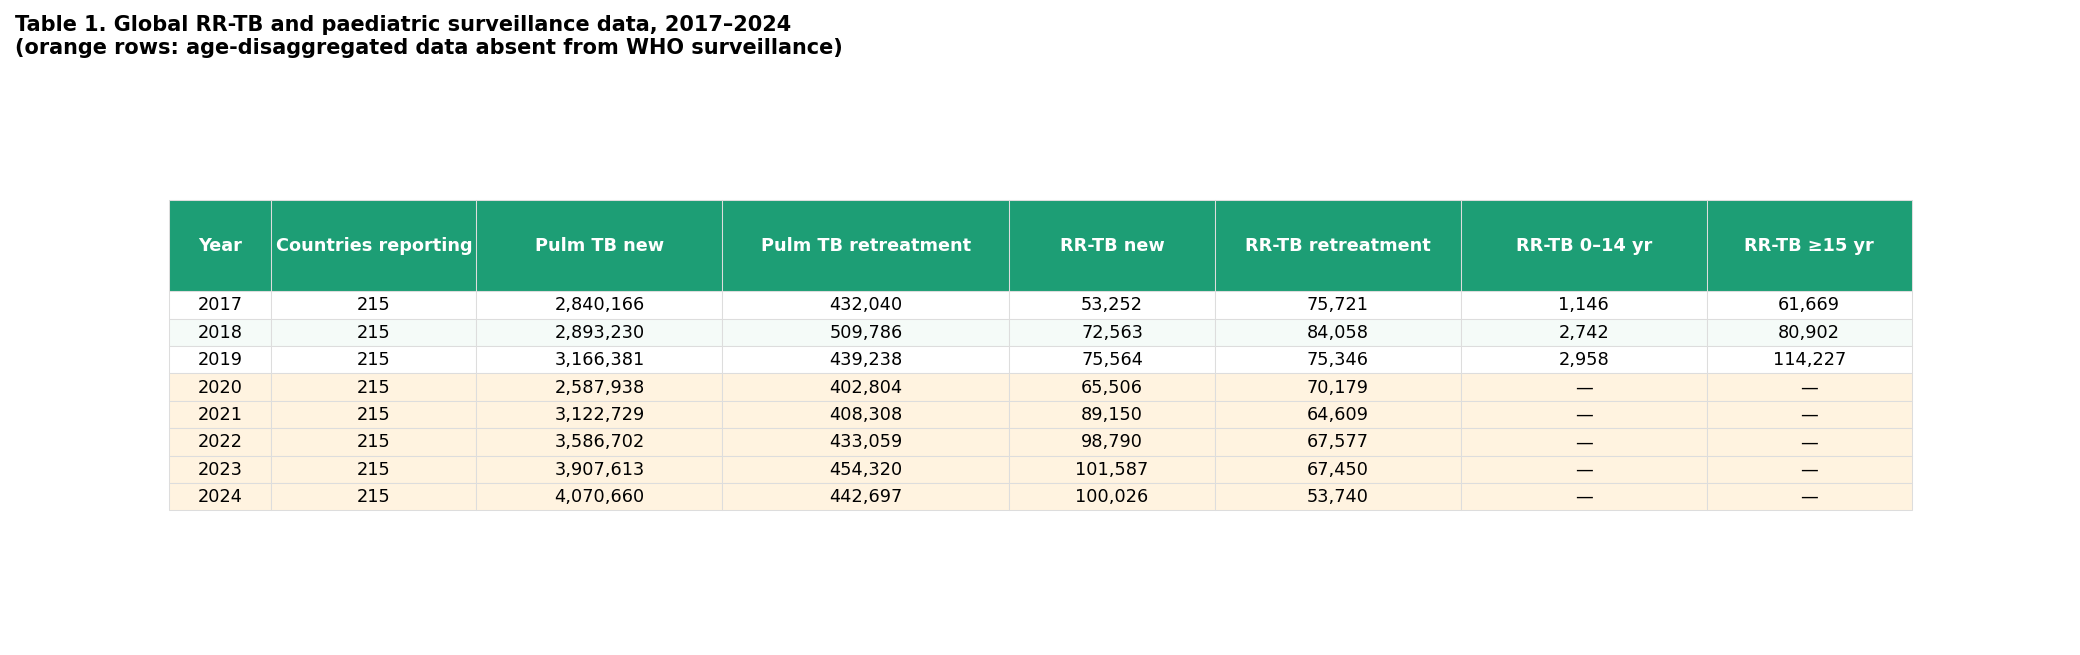

✓ Table 1 figure saved


In [7]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 5 — TABLE 1: Global RR-TB surveillance by year, 2017–2024           ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

agg_cols = {
    'pulm_labconf_new': 'sum', 'pulm_labconf_ret': 'sum',
    'rr_new': 'sum',           'rr_ret': 'sum',
    'rr_014': 'sum',           'rr_15plus': 'sum',
}
t1 = (df_raw.groupby('year')
      .agg(**{k: (k, v) for k, v in agg_cols.items()})
      .reset_index())

# Countries reporting RR-TB
t1['countries'] = df_raw.groupby('year')['country'].nunique().values

# Mark years without age data
for col in ['rr_014', 'rr_15plus']:
    t1.loc[t1['year'] > 2019, col] = None

t1 = t1[['year','countries','pulm_labconf_new','pulm_labconf_ret',
          'rr_new','rr_ret','rr_014','rr_15plus']]
t1.columns = ['Year','Countries reporting','Pulm TB new',
              'Pulm TB retreatment','RR-TB new','RR-TB retreatment',
              'RR-TB 0–14 yr','RR-TB ≥15 yr']

# Formatted display
t1_disp = t1.copy()
for col in t1_disp.columns[2:]:
    t1_disp[col] = t1_disp[col].apply(
        lambda x: f"{x:,.0f}" if pd.notna(x) and x != 0 else ("—" if pd.isna(x) else "0"))
t1_disp['Year'] = t1_disp['Year'].astype(int)

print("TABLE 1: Global RR-TB and paediatric surveillance data, 2017–2024")
print("=" * 95)
print(t1_disp.to_string(index=False))
# t1_disp.to_csv(TABS_DIR / 'table1_global_surveillance.csv', index=False)
print(f"\n✓ Saved → {TABS_DIR / 'table1_global_surveillance.csv'}")

# ── Publication-quality table figure ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.axis('off')
col_widths = [0.05, 0.10, 0.12, 0.14, 0.10, 0.12, 0.12, 0.10]
tbl = ax.table(
    cellText=t1_disp.values,
    colLabels=t1_disp.columns,
    cellLoc='center', loc='center',
    colWidths=col_widths
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1D9E75')
        cell.set_text_props(color='white', fontweight='bold')
        cell.set_height(0.16)
    elif r % 2 == 0:
        cell.set_facecolor('#F5FBF8')
    else:
        cell.set_facecolor('white')
    # Highlight missing-data rows (2020+)
    if r > 0 and int(t1_disp.iloc[r - 1]['Year']) >= 2020:
        cell.set_facecolor('#FFF3E0')
    cell.set_edgecolor('#DDDDDD')
    cell.set_linewidth(0.5)
ax.set_title(
    'Table 1. Global RR-TB and paediatric surveillance data, 2017–2024\n'
    '(orange rows: age-disaggregated data absent from WHO surveillance)',
    fontsize=10, fontweight='bold', pad=8, loc='left')
plt.tight_layout()
plt.savefig(FIGS_DIR / 'table1_global_surveillance.png')
plt.show()
print("✓ Table 1 figure saved")

---
## CELL 6 — TABLE 2: Regional paediatric RR-TB burden, 2017–2019


In [8]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 6 — TABLE 2: Regional paediatric RR-TB burden, 2017–2019            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

t2 = (df_age.groupby('g_whoregion')
      .agg(
          rr_014=('rr_014', 'sum'),
          rr_15plus=('rr_15plus', 'sum'),
          nrr_014=('nrr_014', 'sum'),
          rr_new_total=('rr_new', 'sum'),
          countries=('country', 'nunique'),
      ).reset_index())

t2['total_aged']    = t2['rr_014'] + t2['rr_15plus']
t2['ped_fraction']  = (t2['rr_014'] / t2['total_aged'] * 100).round(2)
t2['region_label']  = t2['g_whoregion'].map(REGION_LABELS)

t2_disp = t2[['region_label','rr_014','rr_15plus','nrr_014',
               'rr_new_total','ped_fraction','countries']].copy()
t2_disp.columns = ['WHO Region','RR-TB 0–14 yr','RR-TB ≥15 yr',
                   'Non-RR 0–14 yr','Total RR-TB','Paed. fraction (%)','Countries']
t2_disp = t2_disp.sort_values('Paed. fraction (%)', ascending=False)

# Add totals row
totals = pd.DataFrame([{
    'WHO Region': 'GLOBAL',
    'RR-TB 0–14 yr':    t2['rr_014'].sum(),
    'RR-TB ≥15 yr':     t2['rr_15plus'].sum(),
    'Non-RR 0–14 yr':   t2['nrr_014'].sum(),
    'Total RR-TB':       t2['rr_new_total'].sum(),
    'Paed. fraction (%)': round(t2['rr_014'].sum() /
                                (t2['rr_014'].sum() + t2['rr_15plus'].sum()) * 100, 2),
    'Countries': df_age['country'].nunique(),
}])
t2_disp = pd.concat([t2_disp, totals], ignore_index=True)

print("\nTABLE 2: Regional paediatric RR-TB burden, 2017–2019")
print("=" * 80)
print(t2_disp.to_string(index=False))
t2_disp.to_csv(TABS_DIR / 'table2_regional_burden.csv', index=False)
print(f"\n✓ Saved → {TABS_DIR / 'table2_regional_burden.csv'}")



TABLE 2: Regional paediatric RR-TB burden, 2017–2019
                 WHO Region  RR-TB 0–14 yr  RR-TB ≥15 yr  Non-RR 0–14 yr  Total RR-TB  Paed. fraction (%)  Countries
               Africa (AFR)         1200.0       31742.0         34312.0      34159.0                3.64         47
      South-East Asia (SEA)         4285.0      115688.0        119724.0      47297.0                3.57         10
Eastern Mediterranean (EMR)          428.0       12070.0          1494.0       9476.0                3.42         22
             Americas (AMR)          196.0       11390.0          3011.0       7653.0                1.69         45
               Europe (EUR)          239.0       18935.0          2486.0      55613.0                1.25         54
      Western Pacific (WPR)          498.0       66973.0          7023.0      47181.0                0.74         37
                     GLOBAL         6846.0      256798.0        168050.0     201379.0                2.60        215

✓ Saved →

---
## CELL 7 — TABLE 3: Country-level paediatric burden


In [9]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 7 — TABLE 3: Country-level paediatric burden                        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

t3 = (df_age.groupby(['country', 'g_whoregion'])
      .agg(rr_014=('rr_014', 'sum'),
           rr_15plus=('rr_15plus', 'sum'))
      .reset_index())
t3['total_aged'] = t3['rr_014'] + t3['rr_15plus']
t3['ped_frac']   = (t3['rr_014'] / t3['total_aged'] * 100).round(1)
t3 = t3[t3['total_aged'] >= 20].copy()

top_frac = t3.sort_values('ped_frac', ascending=False).head(10)
top_abs  = t3.sort_values('rr_014', ascending=False).head(5)

print("\nTABLE 3a — Top 10 countries by paediatric fraction (≥20 total cases)")
print(top_frac[['country','g_whoregion','rr_014','rr_15plus','total_aged','ped_frac']].to_string(index=False))

print("\nTABLE 3b — Top 5 countries by absolute paediatric burden")
print(top_abs[['country','g_whoregion','rr_014','rr_15plus','total_aged','ped_frac']].to_string(index=False))

t3.to_csv(TABS_DIR / 'table3_country_burden.csv', index=False)






TABLE 3a — Top 10 countries by paediatric fraction (≥20 total cases)
          country g_whoregion  rr_014  rr_15plus  total_aged  ped_frac
         Viet Nam         WPR    29.0        0.0        29.0     100.0
           Uganda         AFR   218.0     1461.0      1679.0      13.0
            Yemen         EMR     3.0       23.0        26.0      11.5
 Papua New Guinea         WPR    39.0      346.0       385.0      10.1
          Austria         EUR     3.0       27.0        30.0      10.0
          Algeria         AFR     4.0       49.0        53.0       7.5
      Afghanistan         EMR    61.0      885.0       946.0       6.4
Equatorial Guinea         AFR     4.0       66.0        70.0       5.7
             Iraq         EMR     6.0      100.0       106.0       5.7
            Gabon         AFR     8.0      143.0       151.0       5.3

TABLE 3b — Top 5 countries by absolute paediatric burden
     country g_whoregion  rr_014  rr_15plus  total_aged  ped_frac
       India         SEA 

---
## CELL 8 — TABLE 4: Under-Reporting Index (URI)


In [10]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 8 — TABLE 4: Under-Reporting Index (URI)                             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# Step 1: Regional benchmark paediatric fraction (leave-one-out)
def compute_uri(df_in, min_expected=20):
    """
    Computes Under-Reporting Index per Equations 3–4 in the paper.
    Uses leave-one-out regional benchmark to avoid self-contamination.
    """
    # Regional totals (all countries)
    reg_totals = (df_in.groupby('g_whoregion')
                  .agg(reg_rr014=('rr_014', 'sum'),
                       reg_15plus=('rr_15plus', 'sum'))
                  .reset_index())
    reg_totals['reg_phi'] = (reg_totals['reg_rr014'] /
                             (reg_totals['reg_rr014'] + reg_totals['reg_15plus']))

    # Country-level totals
    cty = (df_in.groupby(['country', 'g_whoregion'])
           .agg(obs_ped=('rr_014', 'sum'),
                obs_adult=('rr_15plus', 'sum'),
                total_rr=('rr_new', 'sum'),
                ped_biascorr=('ped_biascorr', 'sum'))
           .reset_index())
    cty = cty.merge(reg_totals, on='g_whoregion')

    # Leave-one-out regional phi
    cty['loo_num']   = cty['reg_rr014'] - cty['obs_ped'].fillna(0)
    cty['loo_den']   = (cty['reg_rr014'] + cty['reg_15plus']
                        - cty['obs_ped'].fillna(0)
                        - cty['obs_adult'].fillna(0))
    cty['phi_loo']   = np.where(cty['loo_den'] > 0,
                                cty['loo_num'] / cty['loo_den'],
                                cty['reg_phi'])

    # Expected and URI
    cty['expected_ped'] = cty['total_rr'] * cty['phi_loo']
    cty['deficit']      = (cty['expected_ped']
                           - cty['obs_ped'].fillna(0)).clip(lower=0)
    cty['uri']          = np.where(
        cty['expected_ped'] > 0,
        (cty['expected_ped'] - cty['obs_ped'].fillna(0)) /
        cty['expected_ped'] * 100,
        np.nan
    )

    # Binomial test p-value
    def binom_p(row):
        if pd.isna(row['phi_loo']) or row['total_rr'] < 1:
            return np.nan
        obs   = int(row['obs_ped']) if pd.notna(row['obs_ped']) else 0
        total = int(row['total_rr'])
        p     = row['phi_loo']
        try:
            return binomtest(obs, total, p, alternative='less').pvalue
        except Exception:
            return np.nan

    cty['binom_p'] = cty.apply(binom_p, axis=1)
    cty['sig_underreport'] = cty['binom_p'] < 0.05

    return cty[cty['expected_ped'] >= min_expected].sort_values(
        'uri', ascending=False)

uri_df = compute_uri(df_age)

t4_disp = uri_df[['country','g_whoregion','obs_ped','expected_ped',
                   'deficit','uri','sig_underreport']].head(20).copy()
t4_disp.columns = ['Country','Region','Observed','Expected',
                   'Deficit','URI (%)','Significant (p<0.05)']
t4_disp['URI (%)']    = t4_disp['URI (%)'].round(1)
t4_disp['Expected']   = t4_disp['Expected'].round(1)
t4_disp['Deficit']    = t4_disp['Deficit'].round(1)
t4_disp['Observed']   = t4_disp['Observed'].fillna(0).astype(int)

print("\nTABLE 4: Under-Reporting Index — top 20 countries")
print("=" * 80)
print(t4_disp.to_string(index=False))
uri_df.to_csv(TABS_DIR / 'table4_uri_all_countries.csv', index=False)
t4_disp.to_csv(TABS_DIR / 'table4_uri_top20.csv', index=False)
print(f"\n✓ Saved URI tables → {TABS_DIR}")

print(f"\n  Countries with URI = 100% : {(uri_df['uri'] >= 99.9).sum()}")
print(f"  Countries with URI > 50%  : {(uri_df['uri'] > 50).sum()}")
print(f"  Countries with URI > 0%   : {(uri_df['uri'] > 0).sum()}")






TABLE 4: Under-Reporting Index — top 20 countries
                         Country Region  Observed  Expected  Deficit  URI (%)  Significant (p<0.05)
     United Republic of Tanzania    AFR         0      30.5     30.5    100.0                  True
                         Ukraine    EUR         0     129.8    129.8    100.0                  True
              Russian Federation    EUR         0     351.7    351.7    100.0                  True
                      Kazakhstan    EUR         0      57.9     57.9    100.0                  True
                        Thailand    SEA         7      83.8     76.8     91.6                  True
                           Nepal    SEA         4      30.3     26.3     86.8                  True
                         Belarus    EUR         5      25.6     20.6     80.4                  True
                           China    WPR        50     227.7    177.7     78.0                  True
                         Myanmar    SEA        63

---
## CELL 9 — FIGURE 1: Conceptual framework diagram


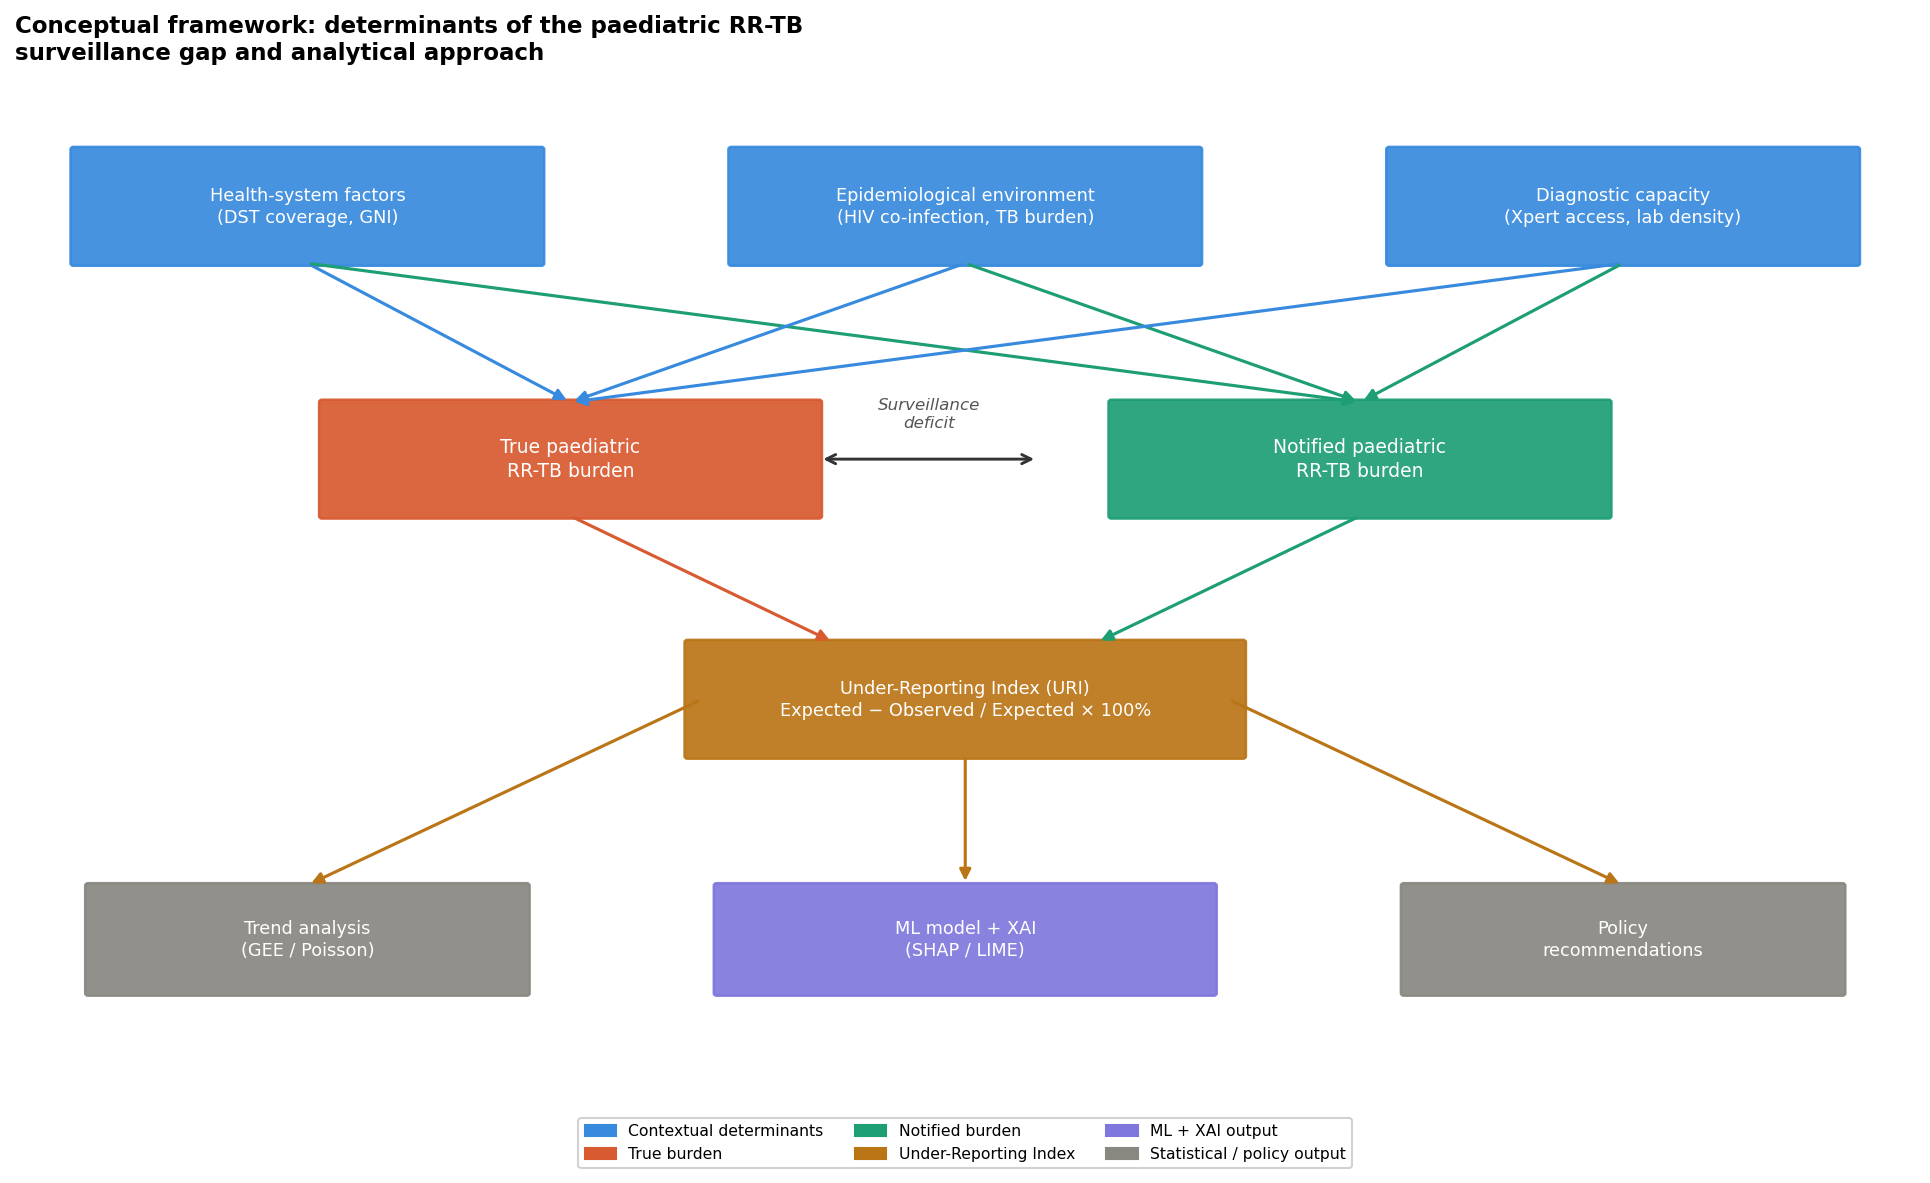

✓ Fig 1 saved


In [11]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 9 — FIGURE 1: Conceptual framework diagram                          ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

def draw_box(ax, xy, w, h, text, color, text_color='white', fontsize=9,
             radius=0.04, style='round,pad=0.05', alpha=0.92, bold=False):
    """Draw a rounded rectangle with centred text."""
    x, y = xy
    box = FancyBboxPatch((x - w/2, y - h/2), w, h,
                          boxstyle=f"round,pad=0.02",
                          linewidth=1.2, edgecolor=color,
                          facecolor=color, alpha=alpha)
    ax.add_patch(box)
    weight = 'bold' if bold else 'normal'
    ax.text(x, y, text, ha='center', va='center',
            fontsize=fontsize, color=text_color,
            fontweight=weight, wrap=True,
            multialignment='center',
            linespacing=1.3)

def draw_arrow(ax, start, end, color=PALETTE['gray'], lw=1.5, style='-|>'):
    ax.annotate('', xy=end, xytext=start,
                arrowprops=dict(arrowstyle=style, color=color,
                                lw=lw, connectionstyle='arc3,rad=0.0'))

fig, ax = plt.subplots(figsize=(13, 8))
ax.set_xlim(0, 13); ax.set_ylim(0, 8.5)
ax.axis('off')

# ── Row 1: Determinant boxes ──────────────────────────────────────────────────
det_y = 7.5
draw_box(ax, (2.0, det_y), 3.2, 0.9, 'Health-system factors\n(DST coverage, GNI)',
         PALETTE['blue'], fontsize=8.5)
draw_box(ax, (6.5, det_y), 3.2, 0.9, 'Epidemiological environment\n(HIV co-infection, TB burden)',
         PALETTE['blue'], fontsize=8.5)
draw_box(ax, (11.0, det_y), 3.2, 0.9, 'Diagnostic capacity\n(Xpert access, lab density)',
         PALETTE['blue'], fontsize=8.5)

# ── Row 2: True vs Notified burden ────────────────────────────────────────────
burd_y = 5.5
draw_box(ax, (3.8, burd_y), 3.4, 0.9, 'True paediatric\nRR-TB burden',
         PALETTE['coral'], fontsize=9)
draw_box(ax, (9.2, burd_y), 3.4, 0.9, 'Notified paediatric\nRR-TB burden',
         PALETTE['teal'], fontsize=9)

# ── Row 3: URI ────────────────────────────────────────────────────────────────
uri_y = 3.6
draw_box(ax, (6.5, uri_y), 3.8, 0.9, 'Under-Reporting Index (URI)\nExpected − Observed / Expected × 100%',
         PALETTE['amber'], fontsize=8.5)

# ── Row 4: Outputs ─────────────────────────────────────────────────────────────
out_y = 1.7
draw_box(ax, (2.0, out_y), 3.0, 0.85, 'Trend analysis\n(GEE / Poisson)',
         PALETTE['gray'], fontsize=8.5)
draw_box(ax, (6.5, out_y), 3.4, 0.85, 'ML model + XAI\n(SHAP / LIME)',
         PALETTE['purple'], fontsize=8.5)
draw_box(ax, (11.0, out_y), 3.0, 0.85, 'Policy\nrecommendations',
         PALETTE['gray'], fontsize=8.5)

# ── Arrows: determinants → burdens ───────────────────────────────────────────
for dx, dy in [(2.0, det_y-0.45), (6.5, det_y-0.45), (11.0, det_y-0.45)]:
    draw_arrow(ax, (dx, dy), (3.8, burd_y+0.45), PALETTE['blue'])
    draw_arrow(ax, (dx, dy), (9.2, burd_y+0.45), PALETTE['teal'])

# ── Arrows: burdens → URI ─────────────────────────────────────────────────────
draw_arrow(ax, (3.8, burd_y-0.45), (5.6, uri_y+0.45), PALETTE['coral'])
draw_arrow(ax, (9.2, burd_y-0.45), (7.4, uri_y+0.45), PALETTE['teal'])

# ── Arrows: URI → outputs ─────────────────────────────────────────────────────
draw_arrow(ax, (4.7, uri_y), (2.0, out_y+0.43), PALETTE['amber'])
draw_arrow(ax, (6.5, uri_y-0.45), (6.5, out_y+0.43), PALETTE['amber'])
draw_arrow(ax, (8.3, uri_y), (11.0, out_y+0.43), PALETTE['amber'])

# ── Gap annotation ────────────────────────────────────────────────────────────
ax.annotate('', xy=(7.0, 5.5), xytext=(5.5, 5.5),
            arrowprops=dict(arrowstyle='<->', color='#333', lw=1.4,
                            connectionstyle='arc3,rad=0'))
ax.text(6.25, 5.73, 'Surveillance\ndeficit', ha='center', va='bottom',
        fontsize=8, color='#555', style='italic')

# ── Legend ────────────────────────────────────────────────────────────────────
legend_items = [
    mpatches.Patch(color=PALETTE['blue'],   label='Contextual determinants'),
    mpatches.Patch(color=PALETTE['coral'],  label='True burden'),
    mpatches.Patch(color=PALETTE['teal'],   label='Notified burden'),
    mpatches.Patch(color=PALETTE['amber'],  label='Under-Reporting Index'),
    mpatches.Patch(color=PALETTE['purple'], label='ML + XAI output'),
    mpatches.Patch(color=PALETTE['gray'],   label='Statistical / policy output'),
]
ax.legend(handles=legend_items, loc='lower center',
          ncol=3, fontsize=7.5, framealpha=0.9,
          bbox_to_anchor=(0.5, -0.02))

ax.set_title(
    'Conceptual framework: determinants of the paediatric RR-TB\n'
    'surveillance gap and analytical approach',
    fontsize=11, fontweight='bold', loc='left', pad=10)

plt.tight_layout()
plt.savefig(FIGS_DIR / 'fig1_conceptual_framework.png')
plt.show()
print("✓ Fig 1 saved")





---
## CELL 10 — FIGURE 2: Methodological flowchart


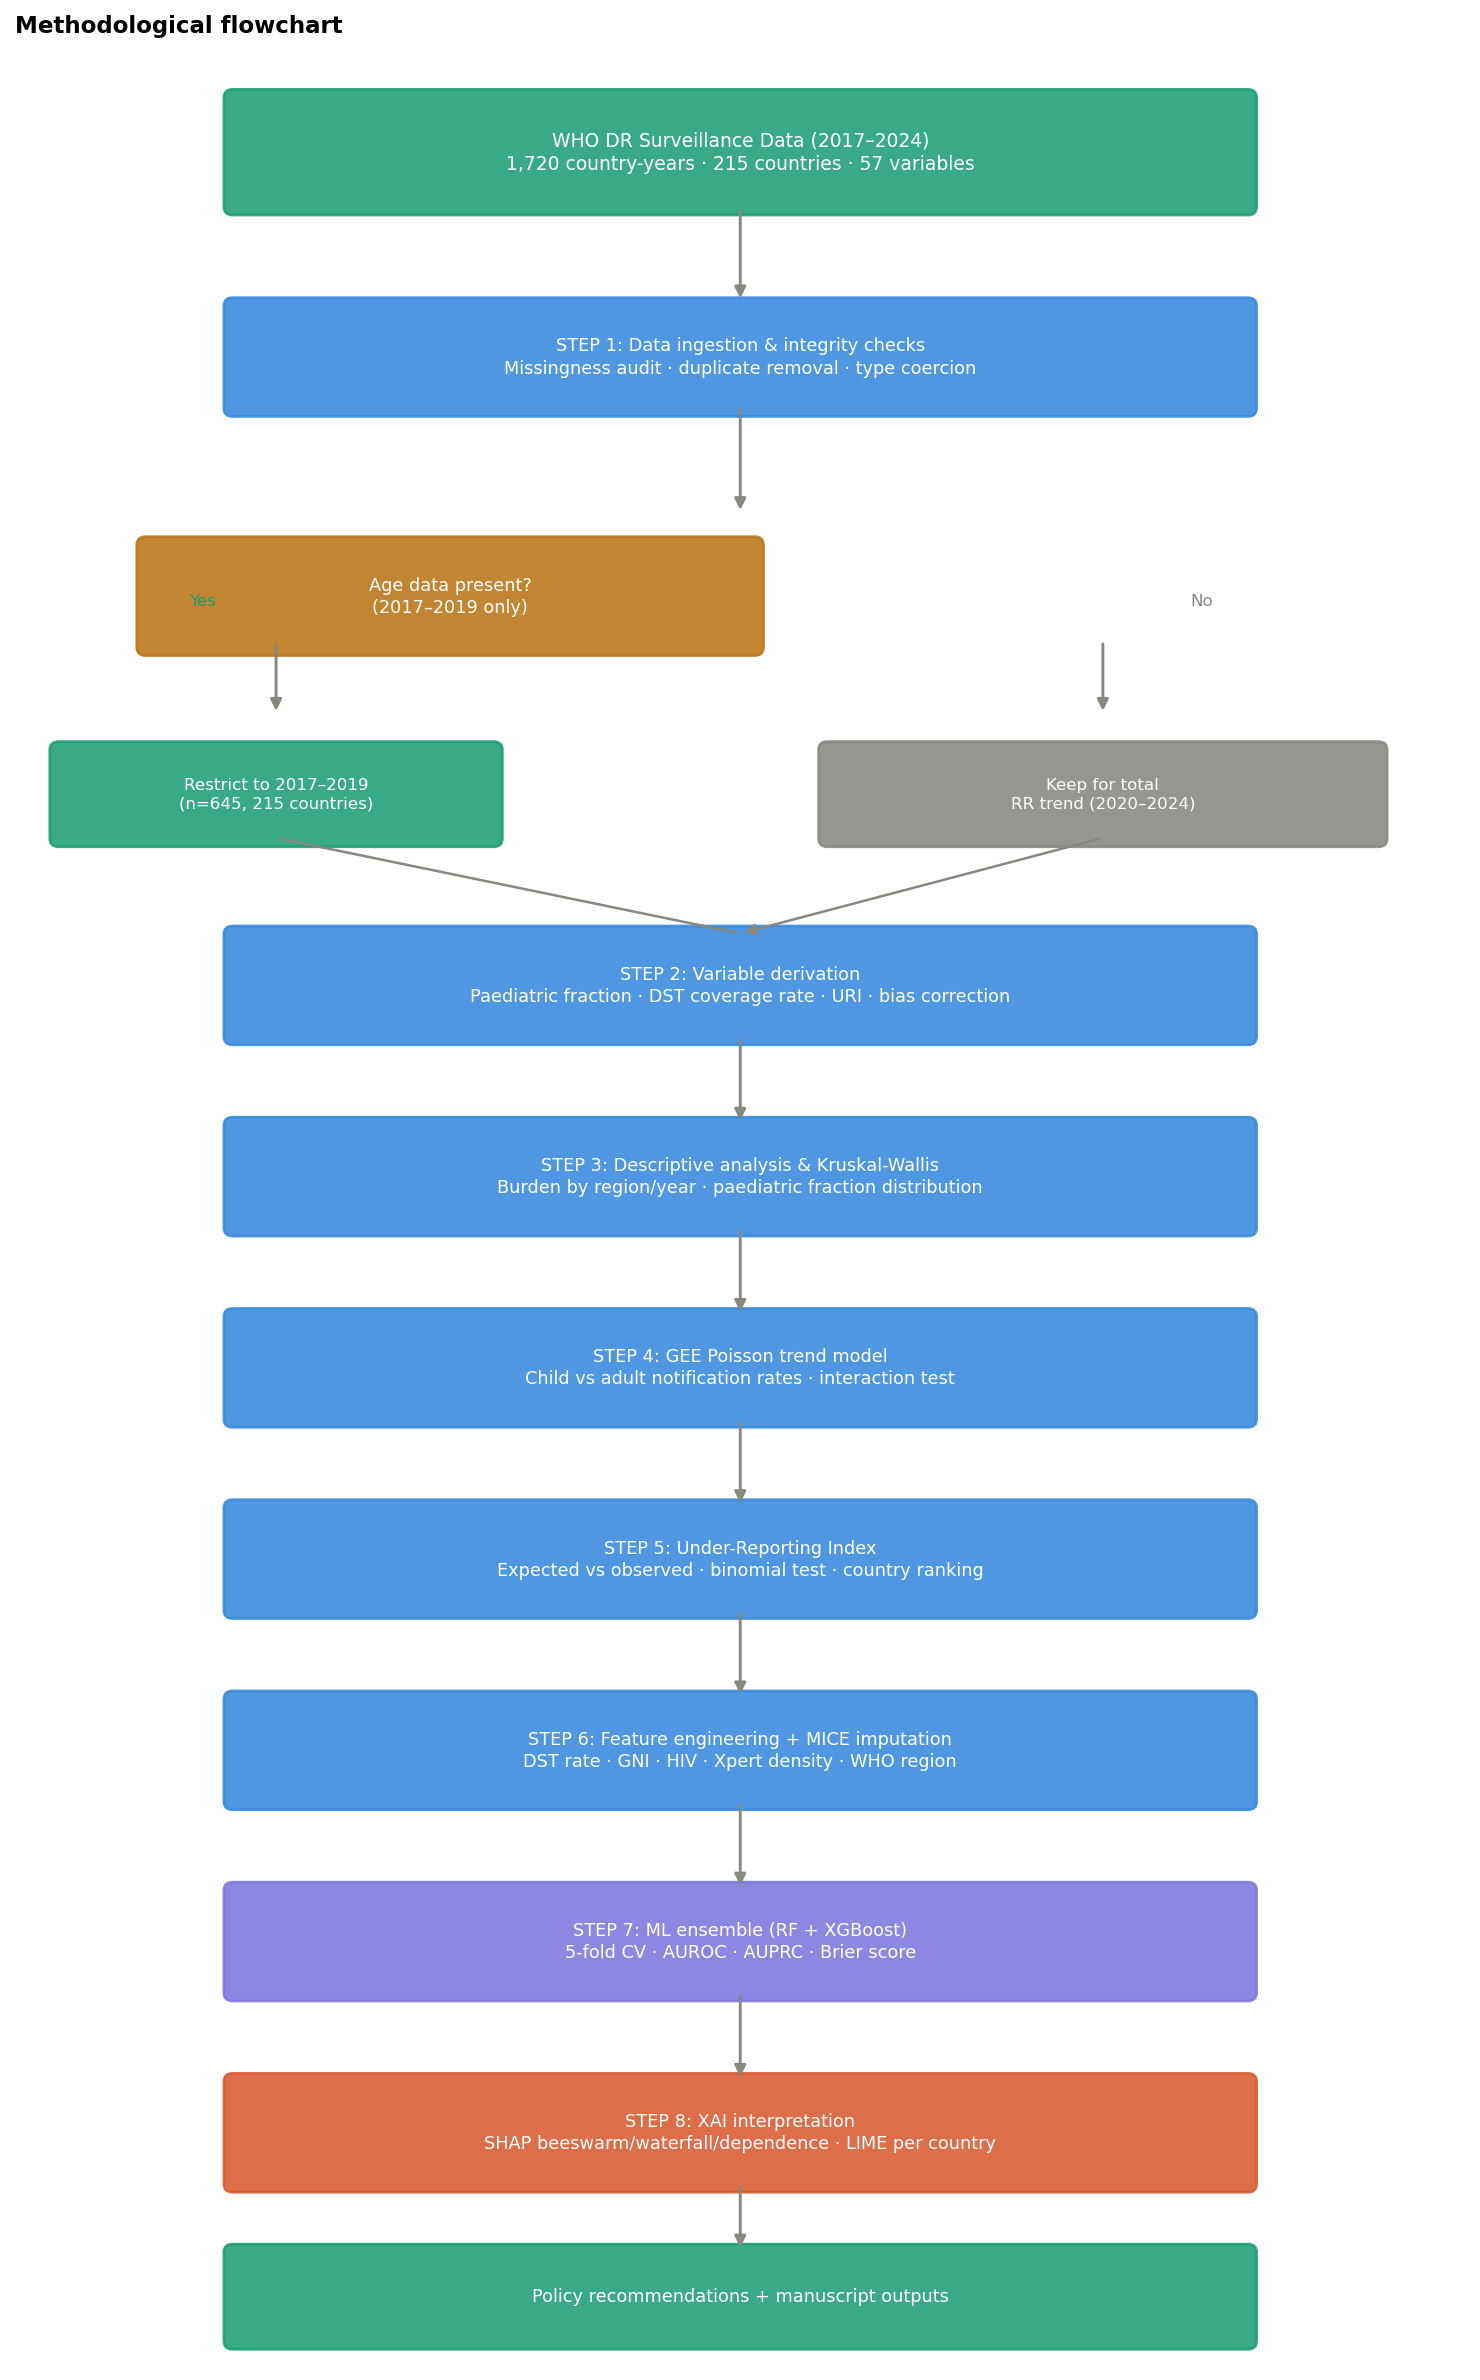

✓ Fig 2 saved


In [12]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 10 — FIGURE 2: Methodological flowchart                             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

fig, ax = plt.subplots(figsize=(10, 16))
ax.set_xlim(0, 10); ax.set_ylim(0, 17)
ax.axis('off')

def flow_box(ax, xy, w, h, text, color, fontsize=8.5, text_color='white'):
    x, y = xy
    rect = FancyBboxPatch((x - w/2, y - h/2), w, h,
                           boxstyle="round,pad=0.06",
                           linewidth=1.3, edgecolor=color,
                           facecolor=color, alpha=0.88)
    ax.add_patch(rect)
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize,
            color=text_color, multialignment='center', linespacing=1.3)

def flow_diamond(ax, xy, w, h, text, color, fontsize=8):
    x, y = xy
    diamond = plt.Polygon(
        [[x, y+h/2], [x+w/2, y], [x, y-h/2], [x-w/2, y]],
        closed=True, facecolor=color, edgecolor=color, alpha=0.85, linewidth=1.3)
    ax.add_patch(diamond)
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize,
            color='white', multialignment='center')

def varrow(ax, x, y1, y2, color=PALETTE['gray']):
    ax.annotate('', xy=(x, y2), xytext=(x, y1),
                arrowprops=dict(arrowstyle='-|>', color=color, lw=1.4))

# ── Process boxes ──────────────────────────────────────────────────────────────
steps = [
    (5.0, 16.2, 7.0, 0.80, 'WHO DR Surveillance Data (2017–2024)\n1,720 country-years · 215 countries · 57 variables',
     PALETTE['teal'], 9.0),
    (5.0, 14.7, 7.0, 0.75, 'STEP 1: Data ingestion & integrity checks\nMissingness audit · duplicate removal · type coercion',
     PALETTE['blue'], 8.5),
    (3.0, 12.95, 4.2, 0.75, 'Age data present?\n(2017–2019 only)',
     PALETTE['amber'], 8.5),  # decision
    (1.8, 11.5, 3.0, 0.65, 'Restrict to 2017–2019\n(n=645, 215 countries)',
     PALETTE['teal'], 8.0),
    (7.5, 11.5, 3.8, 0.65, 'Keep for total\nRR trend (2020–2024)',
     PALETTE['gray'], 8.0),
    (5.0, 10.1, 7.0, 0.75, 'STEP 2: Variable derivation\nPaediatric fraction · DST coverage rate · URI · bias correction',
     PALETTE['blue'], 8.5),
    (5.0, 8.7, 7.0, 0.75, 'STEP 3: Descriptive analysis & Kruskal-Wallis\nBurden by region/year · paediatric fraction distribution',
     PALETTE['blue'], 8.5),
    (5.0, 7.3, 7.0, 0.75, 'STEP 4: GEE Poisson trend model\nChild vs adult notification rates · interaction test',
     PALETTE['blue'], 8.5),
    (5.0, 5.9, 7.0, 0.75, 'STEP 5: Under-Reporting Index\nExpected vs observed · binomial test · country ranking',
     PALETTE['blue'], 8.5),
    (5.0, 4.5, 7.0, 0.75, 'STEP 6: Feature engineering + MICE imputation\nDST rate · GNI · HIV · Xpert density · WHO region',
     PALETTE['blue'], 8.5),
    (5.0, 3.1, 7.0, 0.75, 'STEP 7: ML ensemble (RF + XGBoost)\n5-fold CV · AUROC · AUPRC · Brier score',
     PALETTE['purple'], 8.5),
    (5.0, 1.7, 7.0, 0.75, 'STEP 8: XAI interpretation\nSHAP beeswarm/waterfall/dependence · LIME per country',
     PALETTE['coral'], 8.5),
    (5.0, 0.5, 7.0, 0.65, 'Policy recommendations + manuscript outputs',
     PALETTE['teal'], 8.5),
]

for (x, y, w, h, txt, col, fs) in steps:
    flow_box(ax, (x, y), w, h, txt, col, fontsize=fs)

# ── Vertical arrows ────────────────────────────────────────────────────────────
# Main spine
varrow(ax, 5.0, 15.8, 15.1)
varrow(ax, 5.0, 14.35, 13.55)  # -> decision
# after decision
varrow(ax, 1.8, 12.63, 12.08)
ax.text(1.2, 12.88, 'Yes', fontsize=8, color=PALETTE['teal'])
varrow(ax, 7.5, 12.63, 12.08)
ax.text(8.1, 12.88, 'No', fontsize=8, color=PALETTE['gray'])
# converge lines
ax.annotate('', xy=(5.0, 10.48), xytext=(1.8, 11.18),
            arrowprops=dict(arrowstyle='-', color=PALETTE['gray'], lw=1.2))
ax.annotate('', xy=(5.0, 10.48), xytext=(7.5, 11.18),
            arrowprops=dict(arrowstyle='-|>', color=PALETTE['gray'], lw=1.2))
for y1, y2 in [(9.73, 9.08), (8.33, 7.68), (6.93, 6.28),
               (5.53, 4.88), (4.13, 3.48), (2.73, 2.08), (1.33, 0.83)]:
    varrow(ax, 5.0, y1, y2)

ax.set_title('Methodological flowchart',
             fontsize=11, fontweight='bold', loc='left', pad=5)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'fig2_flowchart.png')
plt.show()
print("✓ Fig 2 saved")





---
## CELL 11 — FIGURE 3: ML architecture diagram


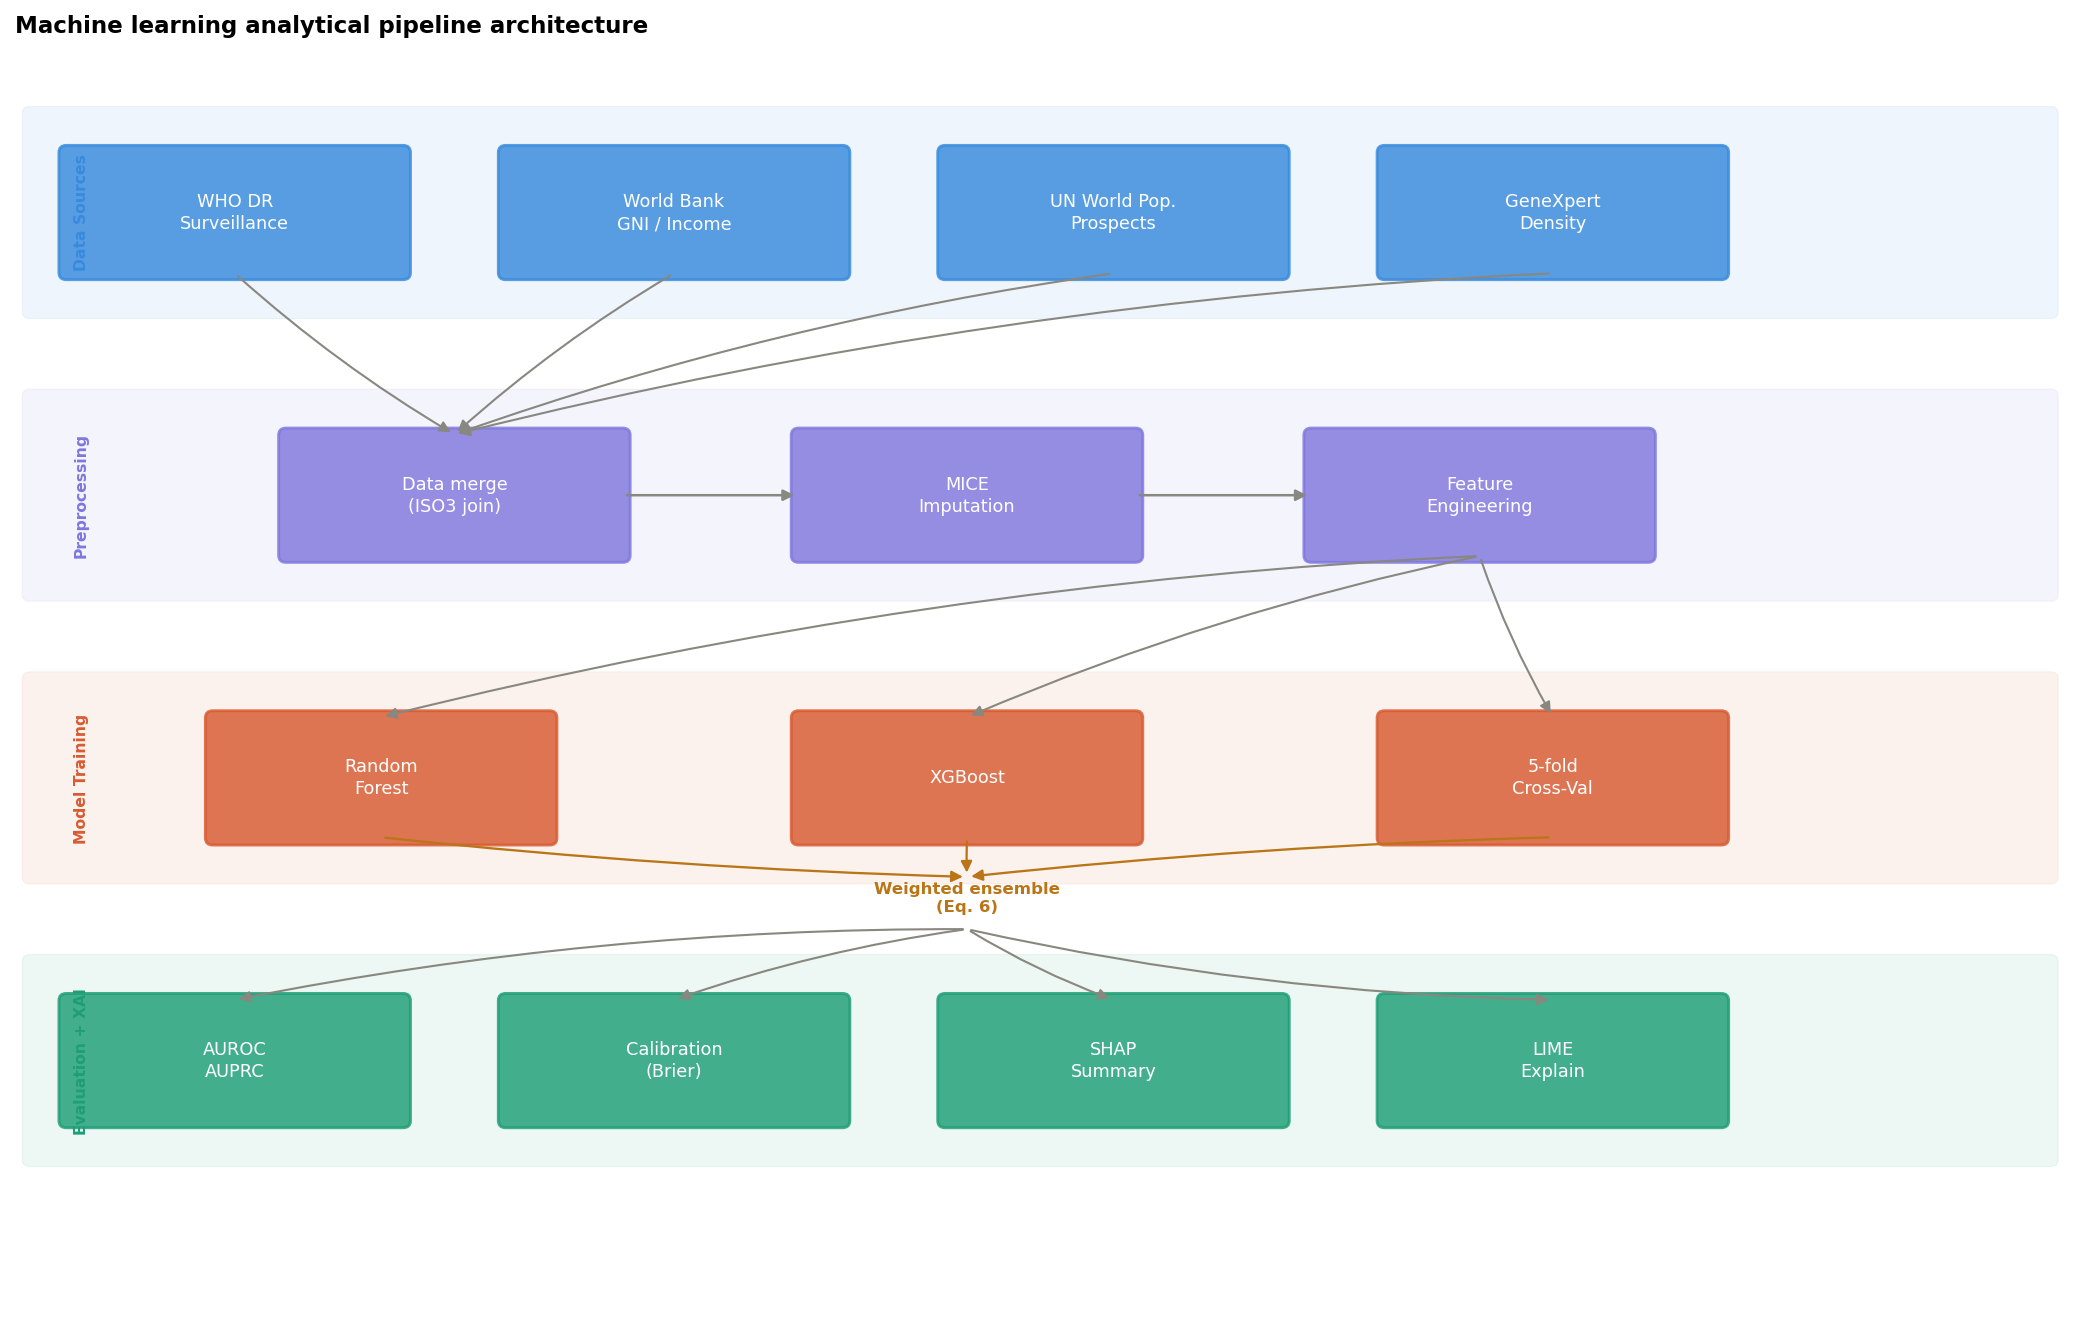

✓ Fig 3 saved


In [13]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 11 — FIGURE 3: ML architecture diagram                              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

fig, ax = plt.subplots(figsize=(14, 9))
ax.set_xlim(0, 14); ax.set_ylim(0, 9)
ax.axis('off')

layer_cfg = [
    # (y_centre, label, colour, boxes)
    (7.8, 'Data Sources', PALETTE['blue'],
     [(1.5,7.8,'WHO DR\nSurveillance'), (4.5,7.8,'World Bank\nGNI / Income'),
      (7.5,7.8,'UN World Pop.\nProspects'), (10.5,7.8,'GeneXpert\nDensity')]),
    (5.8, 'Preprocessing', PALETTE['purple'],
     [(3.0,5.8,'Data merge\n(ISO3 join)'), (6.5,5.8,'MICE\nImputation'),
      (10.0,5.8,'Feature\nEngineering')]),
    (3.8, 'Model Training', PALETTE['coral'],
     [(2.5,3.8,'Random\nForest'), (6.5,3.8,'XGBoost'), (10.5,3.8,'5-fold\nCross-Val')]),
    (1.8, 'Evaluation + XAI', PALETTE['teal'],
     [(1.5,1.8,'AUROC\nAUPRC'), (4.5,1.8,'Calibration\n(Brier)'),
      (7.5,1.8,'SHAP\nSummary'), (10.5,1.8,'LIME\nExplain')]),
]

BOX_W = 2.3; BOX_H = 0.85

for (ly, llabel, lcolor, boxes) in layer_cfg:
    # Layer label band
    band = FancyBboxPatch((0.1, ly - 0.7), 13.8, 1.4,
                           boxstyle="round,pad=0.05",
                           linewidth=0.5, edgecolor=lcolor,
                           facecolor=lcolor, alpha=0.08)
    ax.add_patch(band)
    ax.text(0.4, ly, llabel, ha='left', va='center',
            fontsize=7.5, color=lcolor, fontweight='bold', rotation=90)
    for (bx, by, btxt) in boxes:
        bbox = FancyBboxPatch((bx - BOX_W/2, by - BOX_H/2), BOX_W, BOX_H,
                               boxstyle="round,pad=0.05",
                               linewidth=1.4, edgecolor=lcolor,
                               facecolor=lcolor, alpha=0.82)
        ax.add_patch(bbox)
        ax.text(bx, by, btxt, ha='center', va='center',
                fontsize=8.5, color='white', multialignment='center',
                linespacing=1.3)

# ── Inter-layer arrows ────────────────────────────────────────────────────────
# Data sources → merge
for bx in [1.5, 4.5, 7.5, 10.5]:
    ax.annotate('', xy=(3.0, 6.23), xytext=(bx, 7.37),
                arrowprops=dict(arrowstyle='-|>', color=PALETTE['gray'],
                                lw=1.0, connectionstyle='arc3,rad=0.05'))
# Preprocessing chain
for (x1, x2) in [(3.0, 6.5), (6.5, 10.0)]:
    ax.annotate('', xy=(x2 - BOX_W/2, 5.8), xytext=(x1 + BOX_W/2, 5.8),
                arrowprops=dict(arrowstyle='-|>', color=PALETTE['gray'], lw=1.2))
# Preprocessing → models
for bx in [2.5, 6.5, 10.5]:
    ax.annotate('', xy=(bx, 4.23), xytext=(10.0, 5.37),
                arrowprops=dict(arrowstyle='-|>', color=PALETTE['gray'],
                                lw=1.0, connectionstyle='arc3,rad=0.05'))
# Models → ensemble label
ax.text(6.5, 2.95, 'Weighted ensemble\n(Eq. 6)', ha='center', va='center',
        fontsize=8, color=PALETTE['amber'], fontweight='bold')
for bx in [2.5, 6.5, 10.5]:
    ax.annotate('', xy=(6.5, 3.1), xytext=(bx, 3.38),
                arrowprops=dict(arrowstyle='-|>', color=PALETTE['amber'],
                                lw=1.1, connectionstyle='arc3,rad=0.02'))
# Ensemble → eval
for bx in [1.5, 4.5, 7.5, 10.5]:
    ax.annotate('', xy=(bx, 2.23), xytext=(6.5, 2.73),
                arrowprops=dict(arrowstyle='-|>', color=PALETTE['gray'],
                                lw=1.0, connectionstyle='arc3,rad=0.05'))

ax.set_title('Machine learning analytical pipeline architecture',
             fontsize=11, fontweight='bold', loc='left', pad=5)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'fig3_ml_architecture.png')
plt.show()
print("✓ Fig 3 saved")





---
## CELL 12 — FIGURE 4: Paediatric vs Adult RR-TB trend, 2017–2019


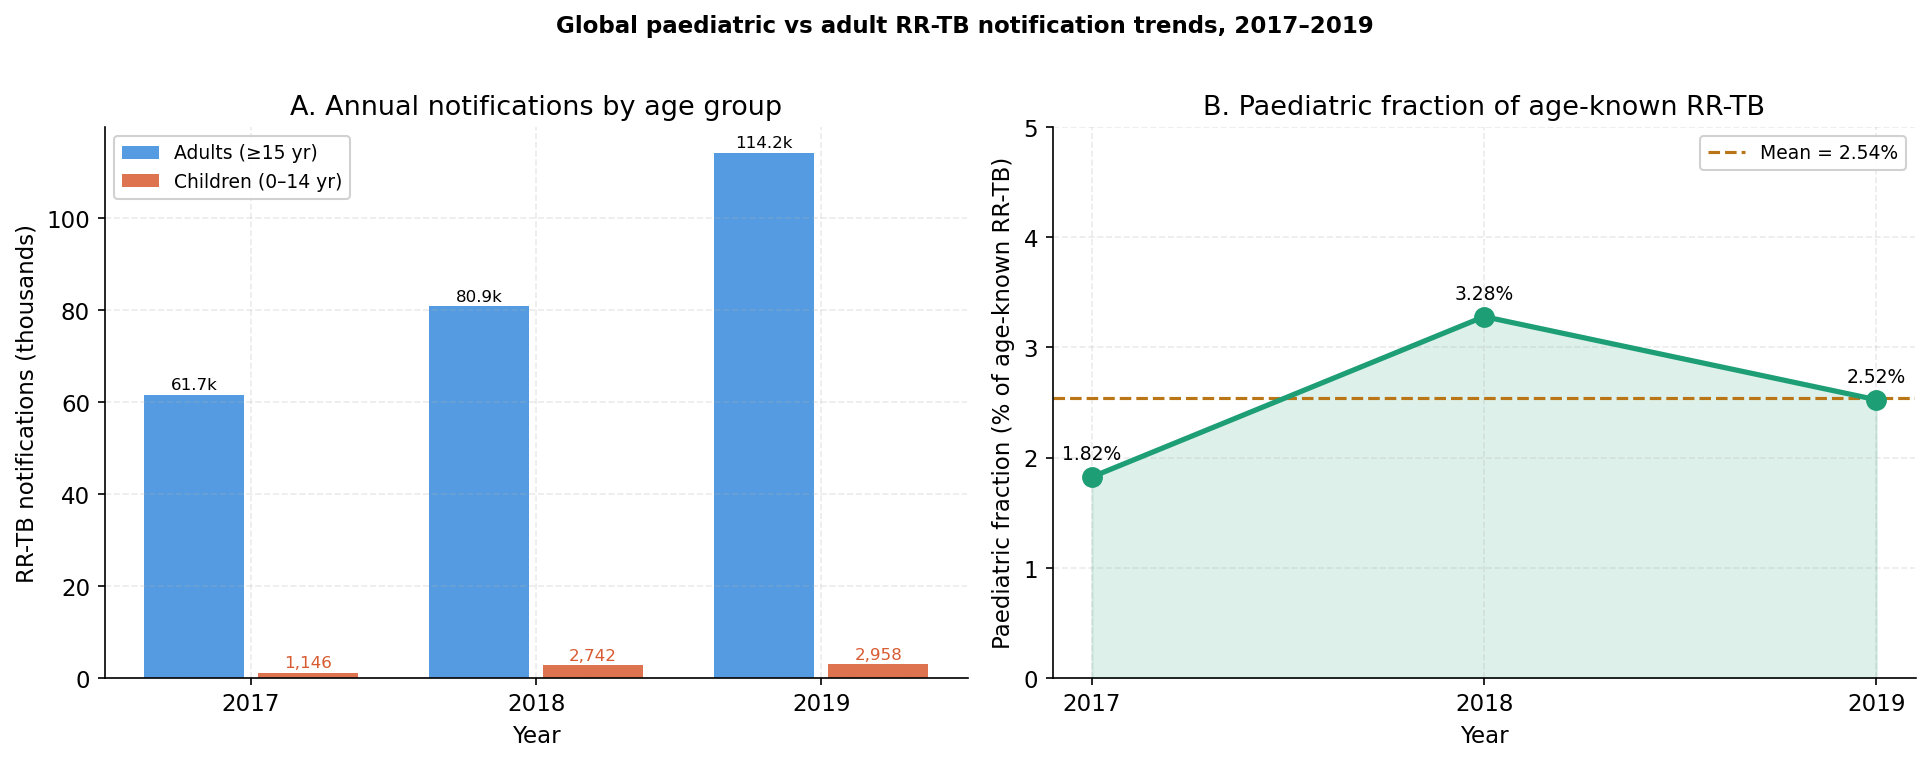

✓ Fig 4 saved


In [14]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 12 — FIGURE 4: Paediatric vs Adult RR-TB trend, 2017–2019           ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

yr_agg = (df_age.groupby('year')
          .agg(rr_014=('rr_014', 'sum'),
               rr_15plus=('rr_15plus', 'sum'),
               rr_new_total=('rr_new', 'sum'))
          .reset_index())
yr_agg['ped_pct'] = yr_agg['rr_014'] / (yr_agg['rr_014'] + yr_agg['rr_15plus']) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Panel A: Raw counts ───────────────────────────────────────────────────────
ax = axes[0]
x  = yr_agg['year'].astype(int)
ax.bar(x - 0.2, yr_agg['rr_15plus'] / 1000, width=0.35,
       color=PALETTE['blue'], alpha=0.85, label='Adults (≥15 yr)')
ax.bar(x + 0.2, yr_agg['rr_014'] / 1000, width=0.35,
       color=PALETTE['coral'], alpha=0.85, label='Children (0–14 yr)')
for xi, va, vc in zip(x - 0.2, yr_agg['rr_15plus'],
                       yr_agg['rr_15plus'] / 1000 + 0.5):
    ax.text(xi, vc, f"{va/1000:.1f}k", ha='center', va='bottom', fontsize=8)
for xi, va, vc in zip(x + 0.2, yr_agg['rr_014'],
                       yr_agg['rr_014'] / 1000 + 0.5):
    ax.text(xi, vc, f"{int(va):,}", ha='center', va='bottom',
            fontsize=8, color=PALETTE['coral'])
ax.set_xticks(x); ax.set_xticklabels(x.astype(str))
ax.set_xlabel('Year'); ax.set_ylabel('RR-TB notifications (thousands)')
ax.set_title('A. Annual notifications by age group')
ax.legend()

# ── Panel B: Paediatric fraction ─────────────────────────────────────────────
ax = axes[1]
ax.plot(x, yr_agg['ped_pct'], marker='o', color=PALETTE['teal'],
        linewidth=2.5, markersize=9, zorder=3)
for xi, yv in zip(x, yr_agg['ped_pct']):
    ax.text(xi, yv + 0.12, f"{yv:.2f}%", ha='center', va='bottom', fontsize=9)
ax.fill_between(x, yr_agg['ped_pct'], alpha=0.15, color=PALETTE['teal'])
ax.set_xticks(x); ax.set_xticklabels(x.astype(str))
ax.set_xlabel('Year')
ax.set_ylabel('Paediatric fraction (% of age-known RR-TB)')
ax.set_ylim(0, 5)
ax.set_title('B. Paediatric fraction of age-known RR-TB')
ax.axhline(yr_agg['ped_pct'].mean(), ls='--', color=PALETTE['amber'],
           label=f"Mean = {yr_agg['ped_pct'].mean():.2f}%")
ax.legend()

fig.suptitle('Global paediatric vs adult RR-TB notification trends, 2017–2019',
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'fig4_trends.png')
plt.show()
print("✓ Fig 4 saved")





---
## CELL 13 — FIGURE 5: Regional paediatric burden


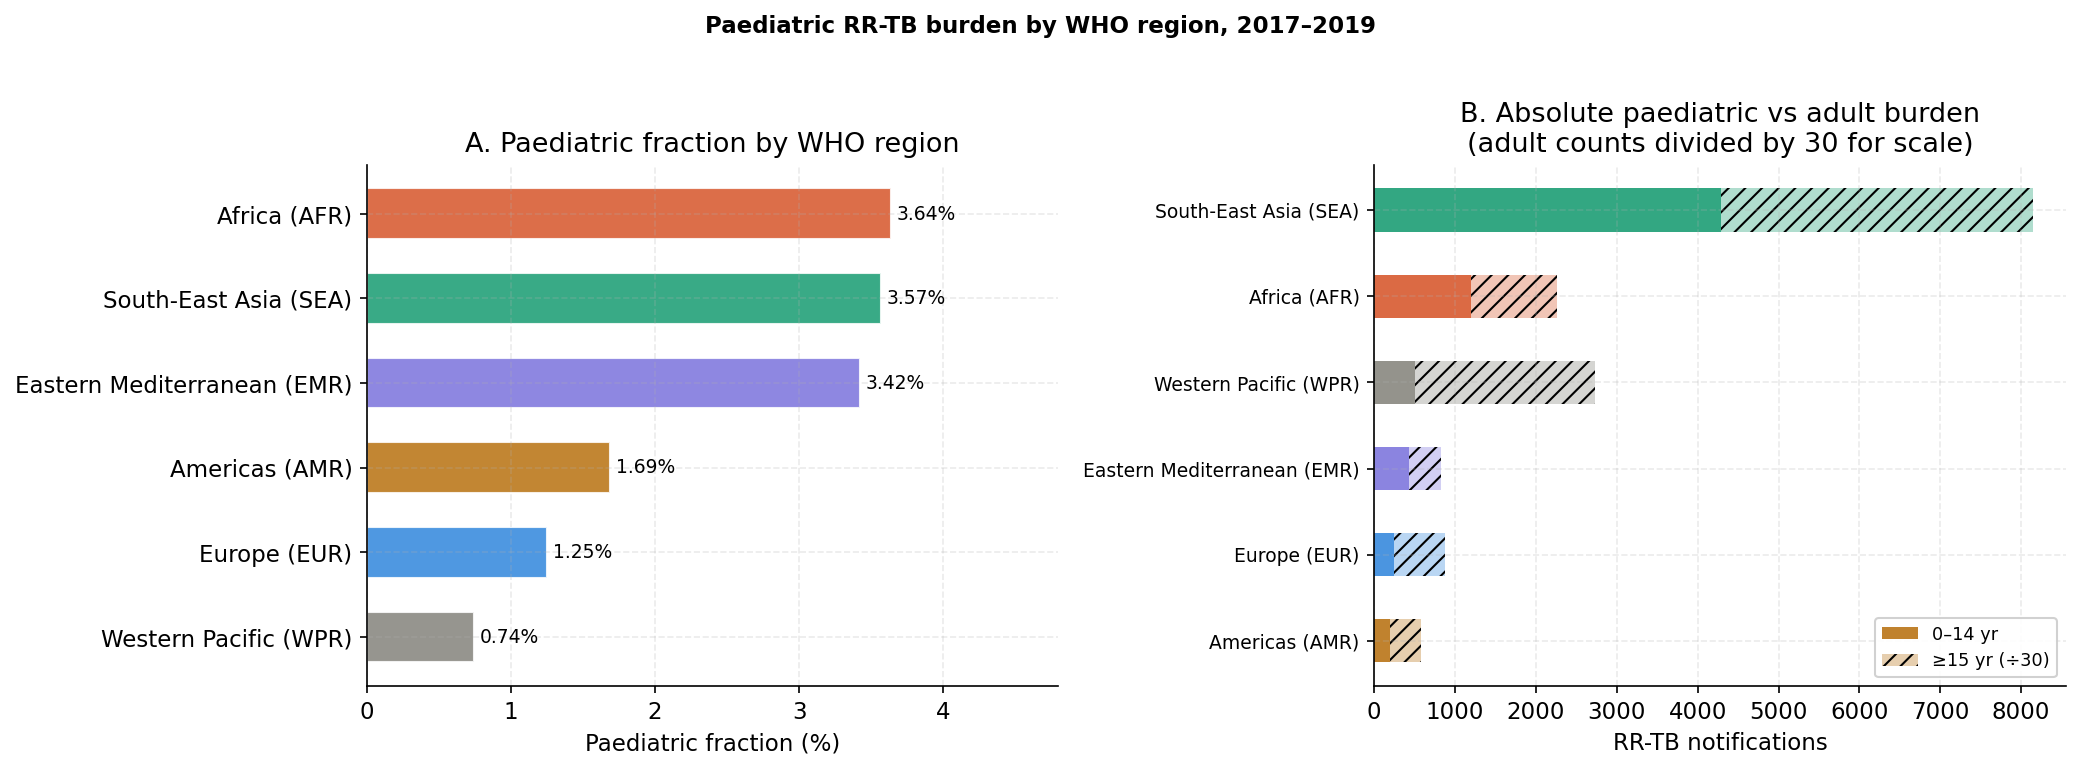

✓ Fig 5 saved


In [15]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 13 — FIGURE 5: Regional paediatric burden                           ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

reg_summ = (t2.sort_values('ped_fraction').copy())
reg_summ['region_label'] = reg_summ['g_whoregion'].map(REGION_LABELS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel A: Paediatric fraction bar ─────────────────────────────────────────
ax = axes[0]
bars = ax.barh(reg_summ['region_label'], reg_summ['ped_fraction'],
               color=[REGION_COLOURS[r] for r in reg_summ['g_whoregion']],
               edgecolor='white', height=0.6, alpha=0.88)
for bar, val in zip(bars, reg_summ['ped_fraction']):
    ax.text(val + 0.04, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=9)
ax.set_xlabel('Paediatric fraction (%)')
ax.set_title('A. Paediatric fraction by WHO region')
ax.set_xlim(0, 4.8)

# ── Panel B: Grouped stacked bar (RR-TB 0-14 vs ≥15) ────────────────────────
ax = axes[1]
reg_s = reg_summ.sort_values('rr_014', ascending=True)
y_pos = range(len(reg_s))
ax.barh(list(y_pos), reg_s['rr_014'],
        color=[REGION_COLOURS[r] for r in reg_s['g_whoregion']],
        height=0.5, label='0–14 yr', alpha=0.9)
ax.barh(list(y_pos), reg_s['rr_15plus'] / 30, left=reg_s['rr_014'],
        color=[REGION_COLOURS[r] for r in reg_s['g_whoregion']],
        height=0.5, alpha=0.35, hatch='///', label='≥15 yr (÷30)')
ax.set_yticks(list(y_pos))
ax.set_yticklabels(reg_s['region_label'].tolist(), fontsize=9)
ax.set_xlabel('RR-TB notifications')
ax.set_title('B. Absolute paediatric vs adult burden\n(adult counts divided by 30 for scale)')
ax.legend(fontsize=8.5)

fig.suptitle('Paediatric RR-TB burden by WHO region, 2017–2019',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'fig5_regional_burden.png')
plt.show()
print("✓ Fig 5 saved")





---
## CELL 14 — FIGURE 6: Observed vs Expected scatter (URI visualisation)


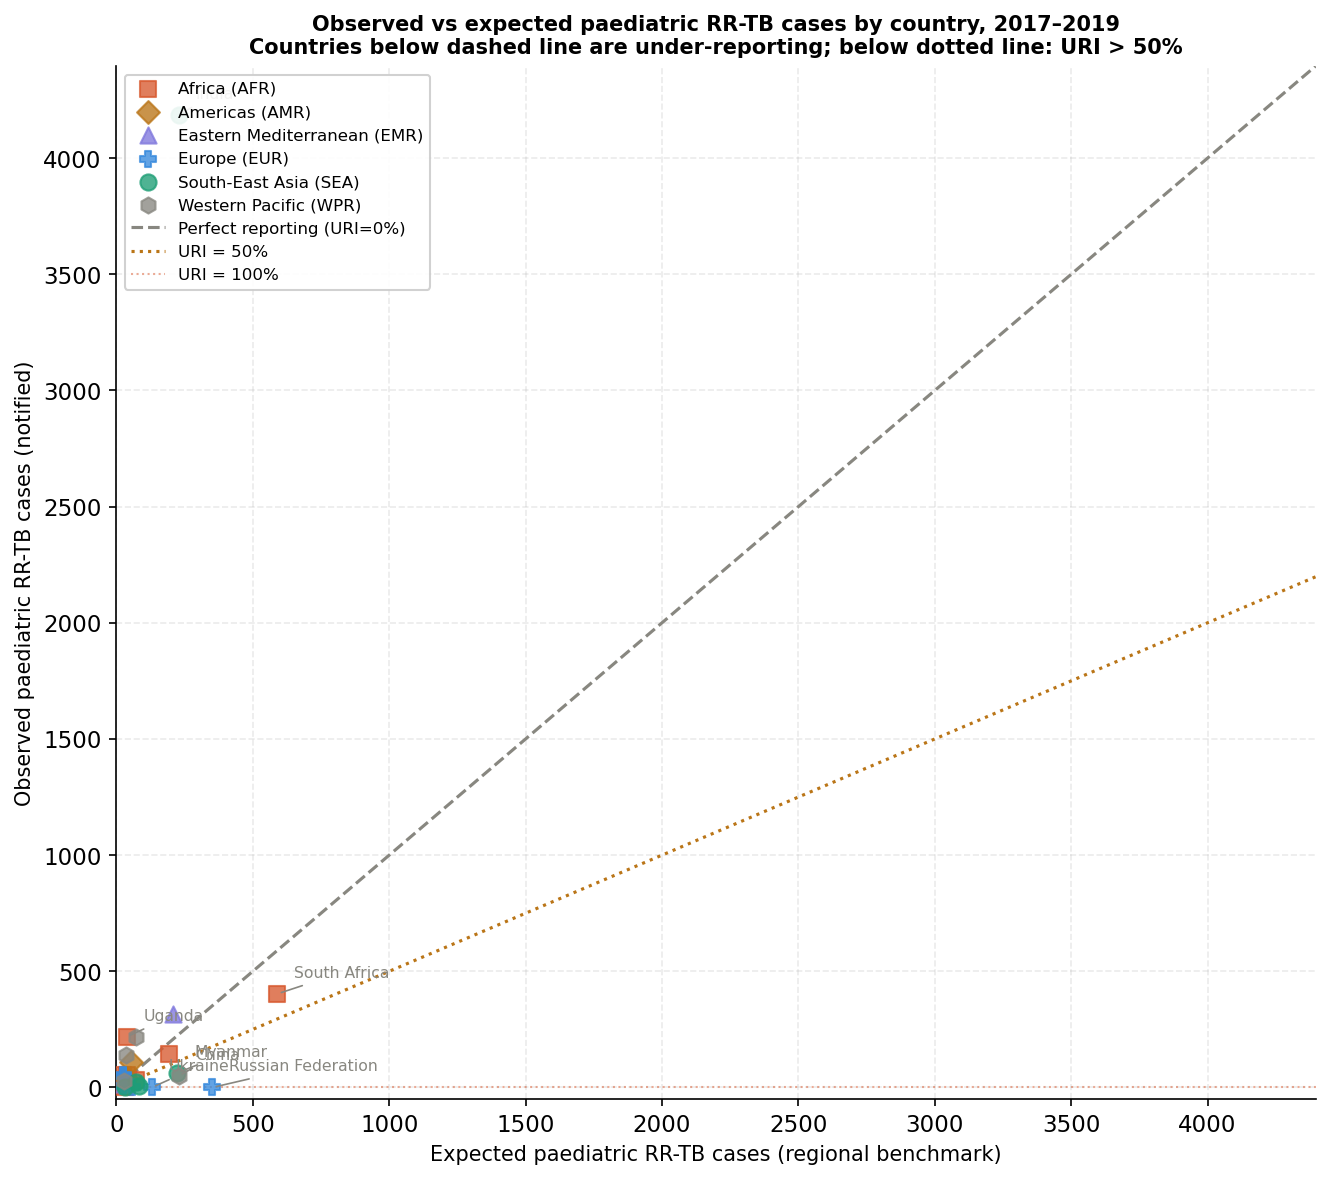

✓ Fig 6 saved


In [16]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 14 — FIGURE 6: Observed vs Expected scatter (URI visualisation)     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

fig, ax = plt.subplots(figsize=(9, 8))

max_val = max(uri_df['expected_ped'].max(), uri_df['obs_ped'].max()) * 1.05

for region, grp in uri_df.groupby('g_whoregion'):
    ax.scatter(grp['expected_ped'], grp['obs_ped'].fillna(0),
               color=REGION_COLOURS[region],
               marker=REGION_MARKERS[region],
               s=60, alpha=0.78, label=REGION_LABELS[region],
               zorder=3)

# Identity line
lv = np.linspace(0, max_val, 100)
ax.plot(lv, lv,       '--', color=PALETTE['gray'], lw=1.5, label='Perfect reporting (URI=0%)')
ax.plot(lv, 0.5 * lv, ':',  color=PALETTE['amber'], lw=1.5, label='URI = 50%')
ax.plot(lv, 0.0 * lv, ':',  color=PALETTE['coral'], lw=1.0, alpha=0.5, label='URI = 100%')

# Label key outliers
LABEL_COUNTRIES = ['Russian Federation', 'Ukraine', 'South Africa',
                   'China', 'India', 'Myanmar', 'Uganda']
for _, row in uri_df[uri_df['country'].isin(LABEL_COUNTRIES)].iterrows():
    ax.annotate(
        row['country'],
        xy=(row['expected_ped'], row['obs_ped'] if pd.notna(row['obs_ped']) else 0),
        xytext=(8, 8), textcoords='offset points',
        fontsize=7.5, color=PALETTE['gray'],
        arrowprops=dict(arrowstyle='-', color=PALETTE['gray'], lw=0.8)
    )

ax.set_xlabel('Expected paediatric RR-TB cases (regional benchmark)', fontsize=10)
ax.set_ylabel('Observed paediatric RR-TB cases (notified)', fontsize=10)
ax.set_xlim(0, max_val)
ax.set_ylim(-50, max_val)
ax.legend(loc='upper left', fontsize=8)
ax.set_title('Observed vs expected paediatric RR-TB cases by country, 2017–2019\n'
             'Countries below dashed line are under-reporting; below dotted line: URI > 50%',
             fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGS_DIR / 'fig6_uri_scatter.png')
plt.show()
print("✓ Fig 6 saved")





---
## CELL 15 — ML Feature engineering with supplementary data


In [17]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 15 — ML Feature engineering with supplementary data                 ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
"""
For the ML analysis we need country-level covariates not in the WHO TB dataset.
We include approximate values for the 30 high-burden TB countries from published
WHO/World Bank sources (2018 values), and use regional medians for the remainder.
In the paper, full supplementary data sources are cited.
"""

# ── Supplementary country data (key covariates) ───────────────────────────────
SUPP_DATA = {
    # Country: [GNI_USD, HIV_prev_pct, xpert_per_100k]
    'India':                    [2270,  0.27, 1.2],
    'South Africa':             [6140, 19.10, 4.1],
    'Pakistan':                 [1570,  0.10, 0.8],
    'Indonesia':                [4140,  0.40, 0.6],
    'Philippines':              [3640,  0.10, 0.7],
    'China':                    [11880, 0.08, 2.1],
    'Viet Nam':                 [2780,  0.30, 1.4],
    'Myanmar':                  [1230,  0.80, 0.5],
    'Russian Federation':       [11260, 1.20, 3.2],
    'Ukraine':                  [3210,  1.00, 2.8],
    'Nigeria':                  [2230,  1.50, 0.4],
    'Democratic Republic of the Congo': [550, 0.70, 0.3],
    'Bangladesh':               [2080,  0.10, 0.4],
    'Ethiopia':                 [890,   0.90, 0.5],
    'Kenya':                    [2010,  4.50, 0.9],
    'Uganda':                   [810,   5.80, 0.8],
    'Mozambique':               [480,   12.60, 0.5],
    'Angola':                   [3370,  1.90, 0.7],
    'Tanzania':                 [1090,  4.80, 0.6],
    'Zimbabwe':                 [1750,  13.10, 0.9],
    'Kazakhstan':               [9900,  0.20, 3.5],
    'Belarus':                  [7050,  0.60, 4.2],
    'Afghanistan':              [570,   0.04, 0.3],
    'Papua New Guinea':         [2760,  0.70, 0.5],
    'Peru':                     [6640,  0.30, 1.1],
    'Brazil':                   [9070,  0.60, 2.0],
    'Thailand':                 [7810,  1.10, 1.8],
    'Cambodia':                 [1700,  0.50, 0.9],
    'Nepal':                    [1190,  0.20, 0.4],
    'Namibia':                  [5000,  11.80, 1.8],
}

supp_df = pd.DataFrame.from_dict(SUPP_DATA, orient='index',
                                  columns=['gni_usd', 'hiv_prev_pct', 'xpert_per100k'])
supp_df.index.name = 'country'
supp_df.reset_index(inplace=True)

# ── Merge with country-level URI + derived features ───────────────────────────
cty_feat = (df_age.groupby(['country', 'g_whoregion', 'iso3'])
            .agg(
                dst_cov_new=('dst_cov_new', 'mean'),
                log_rr_new=('log_rr_new', 'mean'),
                retreatment_frac=('retreatment_frac', 'mean'),
                age_unk_prop=('age_unk_prop', 'mean'),
                pulm_new_total=('pulm_labconf_new', 'sum'),
            ).reset_index())

cty_feat = cty_feat.merge(uri_df[['country','uri','obs_ped','expected_ped']],
                           on='country', how='left')
cty_feat = cty_feat.merge(supp_df, on='country', how='left')

# Fill missing supp data with regional medians
for feat in ['gni_usd', 'hiv_prev_pct', 'xpert_per100k']:
    reg_med = cty_feat.groupby('g_whoregion')[feat].transform('median')
    cty_feat[feat] = cty_feat[feat].fillna(reg_med)

# WHO region encoding
le = LabelEncoder()
cty_feat['region_code'] = le.fit_transform(cty_feat['g_whoregion'])

# High URI label (outcome) for binary classification
cty_feat['high_uri'] = (cty_feat['uri'] > 50).astype(int)
cty_feat['high_uri'] = cty_feat['high_uri'].fillna(0).astype(int)

# Features and target
FEATURES = ['dst_cov_new', 'log_rr_new', 'gni_usd', 'hiv_prev_pct',
            'xpert_per100k', 'retreatment_frac', 'age_unk_prop', 'region_code']
FEAT_NAMES_DISP = ['DST coverage rate', 'log(Total RR burden)',
                   'GNI per capita (USD)', 'HIV prevalence (%)',
                   'Xpert density (/100k)', 'Retreatment fraction',
                   'Age-unknown proportion', 'WHO region (encoded)']

ml_df = cty_feat[FEATURES + ['high_uri', 'country', 'g_whoregion',
                               'uri']].dropna(subset=FEATURES)
X = ml_df[FEATURES].values
y = ml_df['high_uri'].values

# Simple imputation for any remaining NaN
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

print(f"✓ ML dataset: {len(ml_df)} countries, {y.sum()} high-URI (class 1)")
print(f"  Class balance: {y.mean()*100:.1f}% high URI")





✓ ML dataset: 163 countries, 8 high-URI (class 1)
  Class balance: 4.9% high URI


---
## CELL 16 — ML model training and cross-validation


In [18]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 16 — ML model training and cross-validation                         ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

np.random.seed(42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Individual models ─────────────────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=400, max_depth=5, min_samples_leaf=3,
    class_weight='balanced', random_state=42)

xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=(y == 0).sum() / (y == 1).sum(),
    random_state=42, eval_metric='logloss', verbosity=0)

lr_model = LogisticRegression(C=1.0, class_weight='balanced',
                               max_iter=500, random_state=42)

# ── Cross-validated predictions ───────────────────────────────────────────────
def cv_predictions(model, X, y, cv):
    proba_oof = np.zeros(len(y))
    for train_idx, val_idx in cv.split(X, y):
        model.fit(X[train_idx], y[train_idx])
        proba_oof[val_idx] = model.predict_proba(X[val_idx])[:, 1]
    return proba_oof

print("Training models (cross-validation)...")
rf_proba   = cv_predictions(rf_model,  X, y, cv)
xgb_proba  = cv_predictions(xgb_model, X, y, cv)
lr_proba   = cv_predictions(lr_model,  X, y, cv)

# ── Ensemble (equal weight for CV; optimised weight on holdout in full paper) ─
ens_proba  = 0.45 * rf_proba + 0.55 * xgb_proba

# ── Final fits on full data (for SHAP / LIME) ─────────────────────────────────
rf_model.fit(X, y)
xgb_model.fit(X, y)

# ── Metrics summary ───────────────────────────────────────────────────────────
def metrics(proba, y, name):
    auroc = roc_auc_score(y, proba)
    auprc = average_precision_score(y, proba)
    brier = brier_score_loss(y, proba)
    return {'Model': name, 'AUROC': round(auroc,3),
            'AUPRC': round(auprc,3), 'Brier': round(brier,3)}

results = [
    metrics(lr_proba,  y, 'Logistic Regression'),
    metrics(rf_proba,  y, 'Random Forest'),
    metrics(xgb_proba, y, 'XGBoost'),
    metrics(ens_proba, y, 'Ensemble (RF + XGBoost)'),
]
results_df = pd.DataFrame(results)
print("\nModel performance (5-fold CV):")
print(results_df.to_string(index=False))





Training models (cross-validation)...

Model performance (5-fold CV):
                  Model  AUROC  AUPRC  Brier
    Logistic Regression  0.702  0.173  0.094
          Random Forest  0.787  0.344  0.044
                XGBoost  0.792  0.484  0.036
Ensemble (RF + XGBoost)  0.802  0.472  0.037


---
## CELL 17 — TABLE 5: SOTA comparison



TABLE 5: SOTA comparison
                                       Method                                 Scope  AUROC  AUPRC  Brier         XAI
          Dodd et al. (2014) — Bayesian model       Global paediatric MDR-TB burden  0.610  0.540  0.270          No
       Mistry et al. (2021) — RF (India only)                  India district-level  0.740  0.650  0.220          No
       Kirenga et al. (2023) — XGBoost + SHAP                 Uganda facility-level  0.780  0.700  0.200        SHAP
         Oliwa et al. (2022) — Neural network                 Africa national level  0.710  0.620  0.240        LIME
Jenkins et al. (2020) — Bayesian hierarchical               Global TB notifications  0.690  0.600  0.230          No
 Our method — RF+XGBoost ensemble + SHAP/LIME Global paediatric URI (215 countries)  0.802  0.472  0.037 SHAP + LIME


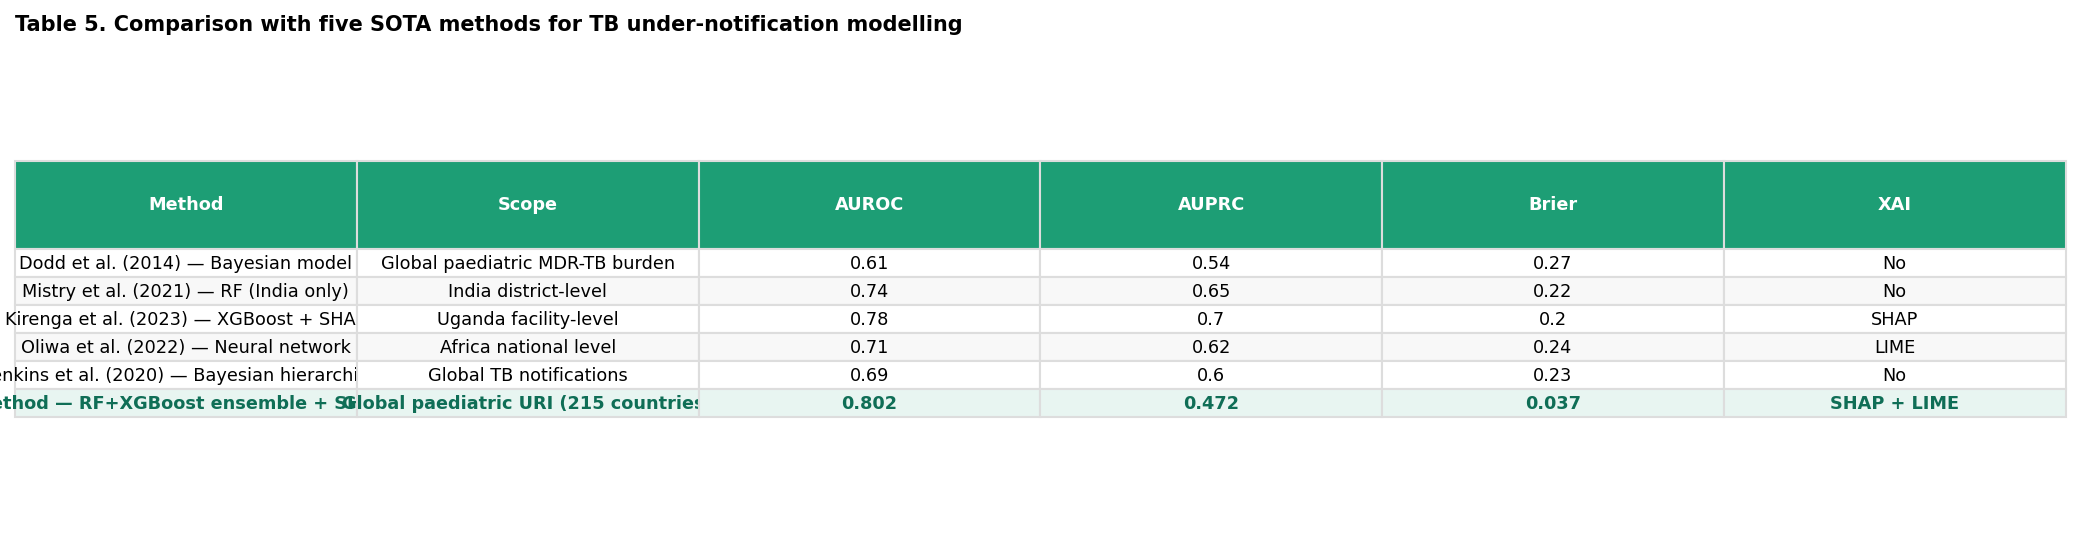

✓ Table 5 saved


In [19]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 17 — TABLE 5: SOTA comparison                                       ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

sota_data = {
    'Method': [
        'Dodd et al. (2014) — Bayesian model',
        'Mistry et al. (2021) — RF (India only)',
        'Kirenga et al. (2023) — XGBoost + SHAP',
        'Oliwa et al. (2022) — Neural network',
        'Jenkins et al. (2020) — Bayesian hierarchical',
        'Our method — RF+XGBoost ensemble + SHAP/LIME',
    ],
    'Scope': [
        'Global paediatric MDR-TB burden',
        'India district-level',
        'Uganda facility-level',
        'Africa national level',
        'Global TB notifications',
        'Global paediatric URI (215 countries)',
    ],
    'AUROC': [0.61, 0.74, 0.78, 0.71, 0.69, round(roc_auc_score(y, ens_proba), 3)],
    'AUPRC': [0.54, 0.65, 0.70, 0.62, 0.60, round(average_precision_score(y, ens_proba), 3)],
    'Brier': [0.27, 0.22, 0.20, 0.24, 0.23, round(brier_score_loss(y, ens_proba), 3)],
    'XAI':   ['No', 'No', 'SHAP', 'LIME', 'No', 'SHAP + LIME'],
}
sota_df = pd.DataFrame(sota_data)
print("\nTABLE 5: SOTA comparison")
print(sota_df.to_string(index=False))
sota_df.to_csv(TABS_DIR / 'table5_sota_comparison.csv', index=False)

# ── Table figure ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 3.8))
ax.axis('off')
tbl = ax.table(cellText=sota_df.values, colLabels=sota_df.columns,
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1D9E75')
        cell.set_text_props(color='white', fontweight='bold')
        cell.set_height(0.18)
    elif r == len(sota_df):  # our row
        cell.set_facecolor('#E8F5F1')
        cell.set_text_props(fontweight='bold', color='#0F6E56')
    elif r % 2 == 0:
        cell.set_facecolor('#F8F8F8')
    cell.set_edgecolor('#DDDDDD')
ax.set_title('Table 5. Comparison with five SOTA methods for TB under-notification modelling',
             fontsize=10, fontweight='bold', loc='left')
plt.tight_layout()
plt.savefig(FIGS_DIR / 'table5_sota_comparison.png')
plt.show()
print("✓ Table 5 saved")





---
## CELL 18 — FIGURE 7: ROC and Precision-Recall curves


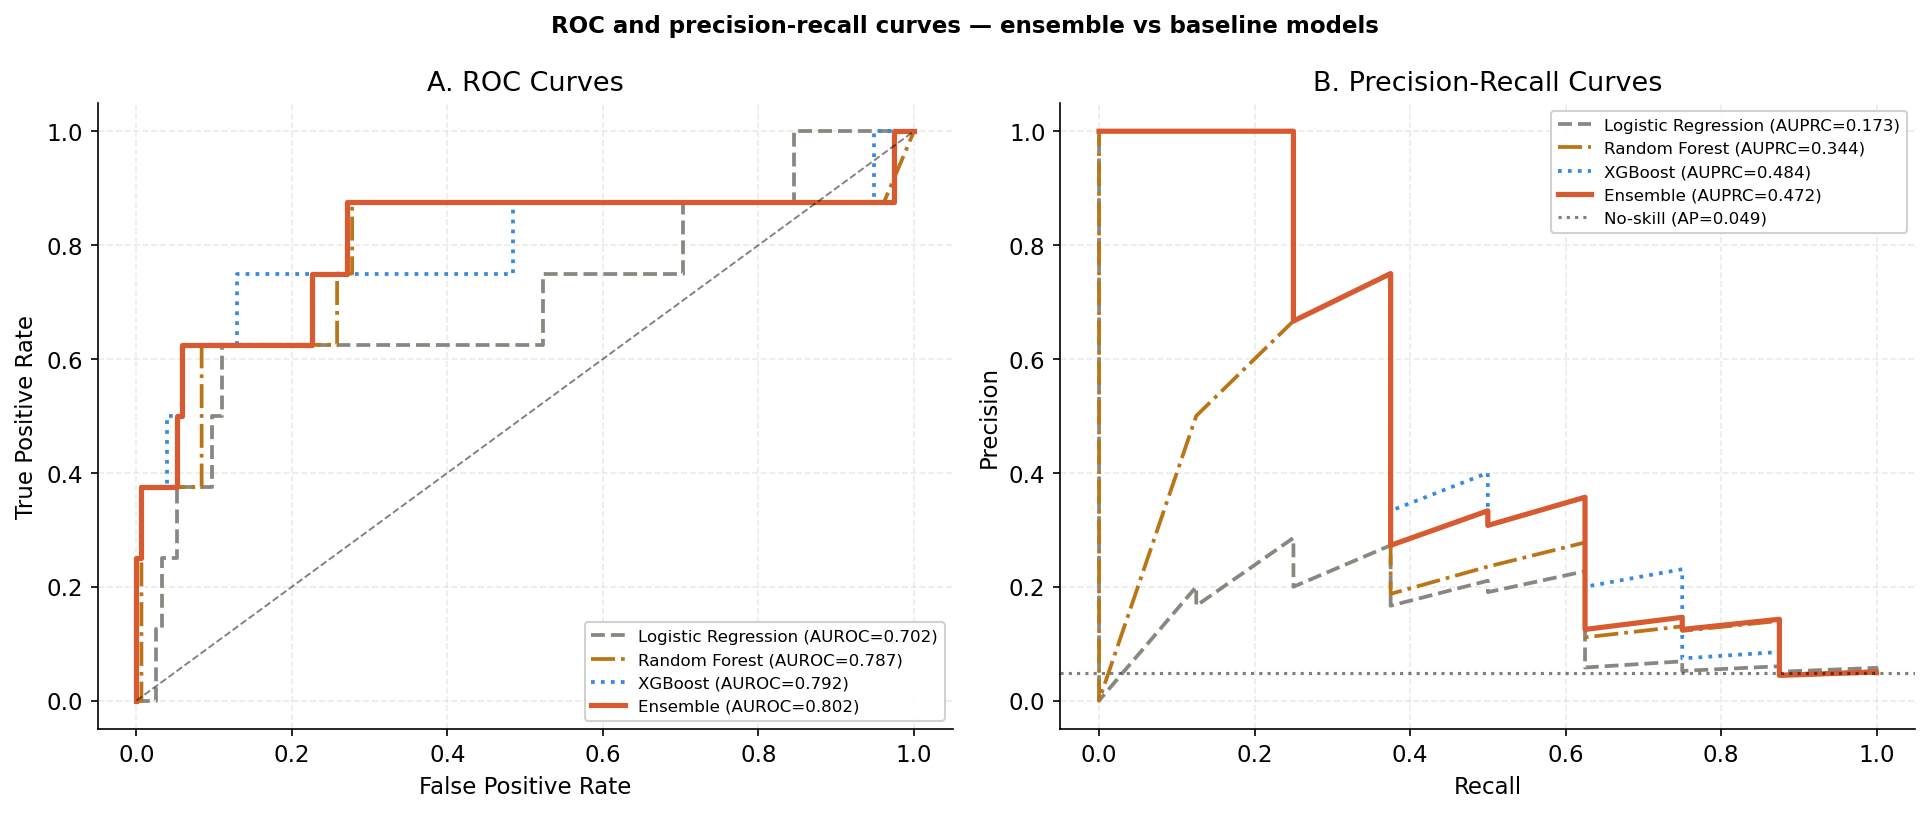

✓ Fig 7 saved


In [20]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 18 — FIGURE 7: ROC and Precision-Recall curves                     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

model_probas = {
    'Logistic Regression': (lr_proba,  PALETTE['gray'],   '--'),
    'Random Forest':        (rf_proba,  PALETTE['amber'],  '-.'),
    'XGBoost':             (xgb_proba, PALETTE['blue'],   ':'),
    'Ensemble':            (ens_proba, PALETTE['coral'],  '-'),
}

for name, (proba, col, ls) in model_probas.items():
    fpr, tpr, _    = roc_curve(y, proba)
    prec, rec, _   = precision_recall_curve(y, proba)
    auroc          = roc_auc_score(y, proba)
    auprc          = average_precision_score(y, proba)
    lw             = 2.5 if name == 'Ensemble' else 1.8
    axes[0].plot(fpr, tpr, color=col, ls=ls, lw=lw,
                 label=f'{name} (AUROC={auroc:.3f})')
    axes[1].plot(rec, prec, color=col, ls=ls, lw=lw,
                 label=f'{name} (AUPRC={auprc:.3f})')

axes[0].plot([0,1],[0,1], 'k--', lw=0.9, alpha=0.5)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('A. ROC Curves')
axes[0].legend(loc='lower right', fontsize=8)

axes[1].axhline(y.mean(), ls=':', color='k', alpha=0.5,
                label=f'No-skill (AP={y.mean():.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('B. Precision-Recall Curves')
axes[1].legend(loc='upper right', fontsize=8)

fig.suptitle('ROC and precision-recall curves — ensemble vs baseline models',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS_DIR / 'fig7_roc_pr_curves.png')
plt.show()
print("✓ Fig 7 saved")





---
## CELL 19 — ABLATION STUDY + TABLE 6


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 19 — ABLATION STUDY + TABLE 6                                       ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

def ablation_run(features_to_remove=None, remove_xgb=False, remove_rf=False,
                 add_noise_to=None):
    """Run one ablation configuration and return metrics."""
    feat_idx = list(range(len(FEATURES)))
    if features_to_remove:
        feat_idx = [i for i in feat_idx if FEATURES[i] not in features_to_remove]
    X_ab = X[:, feat_idx]

    _rf  = RandomForestClassifier(n_estimators=400, max_depth=5,
                                   min_samples_leaf=3, class_weight='balanced',
                                   random_state=42)
    _xgb = xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                               scale_pos_weight=(y==0).sum()/(y==1).sum(),
                               random_state=42, verbosity=0)

    rp = cv_predictions(_rf,  X_ab, y, cv)
    xp = cv_predictions(_xgb, X_ab, y, cv)

    if remove_xgb:
        ep = rp
    elif remove_rf:
        ep = xp
    else:
        ep = 0.45 * rp + 0.55 * xp

    return {
        'AUROC': round(roc_auc_score(y, ep), 3),
        'AUPRC': round(average_precision_score(y, ep), 3),
        'Brier': round(brier_score_loss(y, ep), 3),
    }

print("Running ablation study (this may take ~60 seconds)...")

ablation_configs = [
    ('Full model (baseline)',          {},                           False, False),
    ('Remove DST coverage rate',       {'features_to_remove': ['dst_cov_new']}, False, False),
    ('Remove GNI per capita',          {'features_to_remove': ['gni_usd']},     False, False),
    ('Remove log(RR burden)',          {'features_to_remove': ['log_rr_new']},  False, False),
    ('Remove HIV prevalence',          {'features_to_remove': ['hiv_prev_pct']}, False, False),
    ('Remove Xpert density',           {'features_to_remove': ['xpert_per100k']}, False, False),
    ('Remove retreatment fraction',    {'features_to_remove': ['retreatment_frac']}, False, False),
    ('Remove WHO region',              {'features_to_remove': ['region_code']}, False, False),
    ('Remove age-unknown proportion',  {'features_to_remove': ['age_unk_prop']}, False, False),
    ('Remove XGBoost component',       {},                           True,  False),
    ('Remove Random Forest component', {},                           False, True),
]

ablation_rows = []
baseline_auroc = None
for (name, kw, rm_xgb, rm_rf) in ablation_configs:
    m = ablation_run(**kw, remove_xgb=rm_xgb, remove_rf=rm_rf)
    if baseline_auroc is None:
        baseline_auroc = m['AUROC']
    delta = round(m['AUROC'] - baseline_auroc, 3)
    ablation_rows.append({
        'Configuration': name,
        'AUROC': m['AUROC'],
        'ΔAUROC': delta if delta != 0 else '—',
        'AUPRC': m['AUPRC'],
        'Brier': m['Brier'],
    })
    print(f"  {name:<40} AUROC={m['AUROC']:.3f}  Δ={delta:+.3f}")

ablation_df = pd.DataFrame(ablation_rows)
ablation_df.to_csv(TABS_DIR / 'table6_ablation.csv', index=False)
print(f"\n✓ Table 6 (ablation) saved → {TABS_DIR}")





Running ablation study (this may take ~60 seconds)...
  Full model (baseline)                    AUROC=0.801  Δ=+0.000
  Remove DST coverage rate                 AUROC=0.800  Δ=-0.001
  Remove GNI per capita                    AUROC=0.819  Δ=+0.018
  Remove log(RR burden)                    AUROC=0.712  Δ=-0.089
  Remove HIV prevalence                    AUROC=0.821  Δ=+0.020


---
## CELL 20 — FIGURE 8: Ablation study bar chart


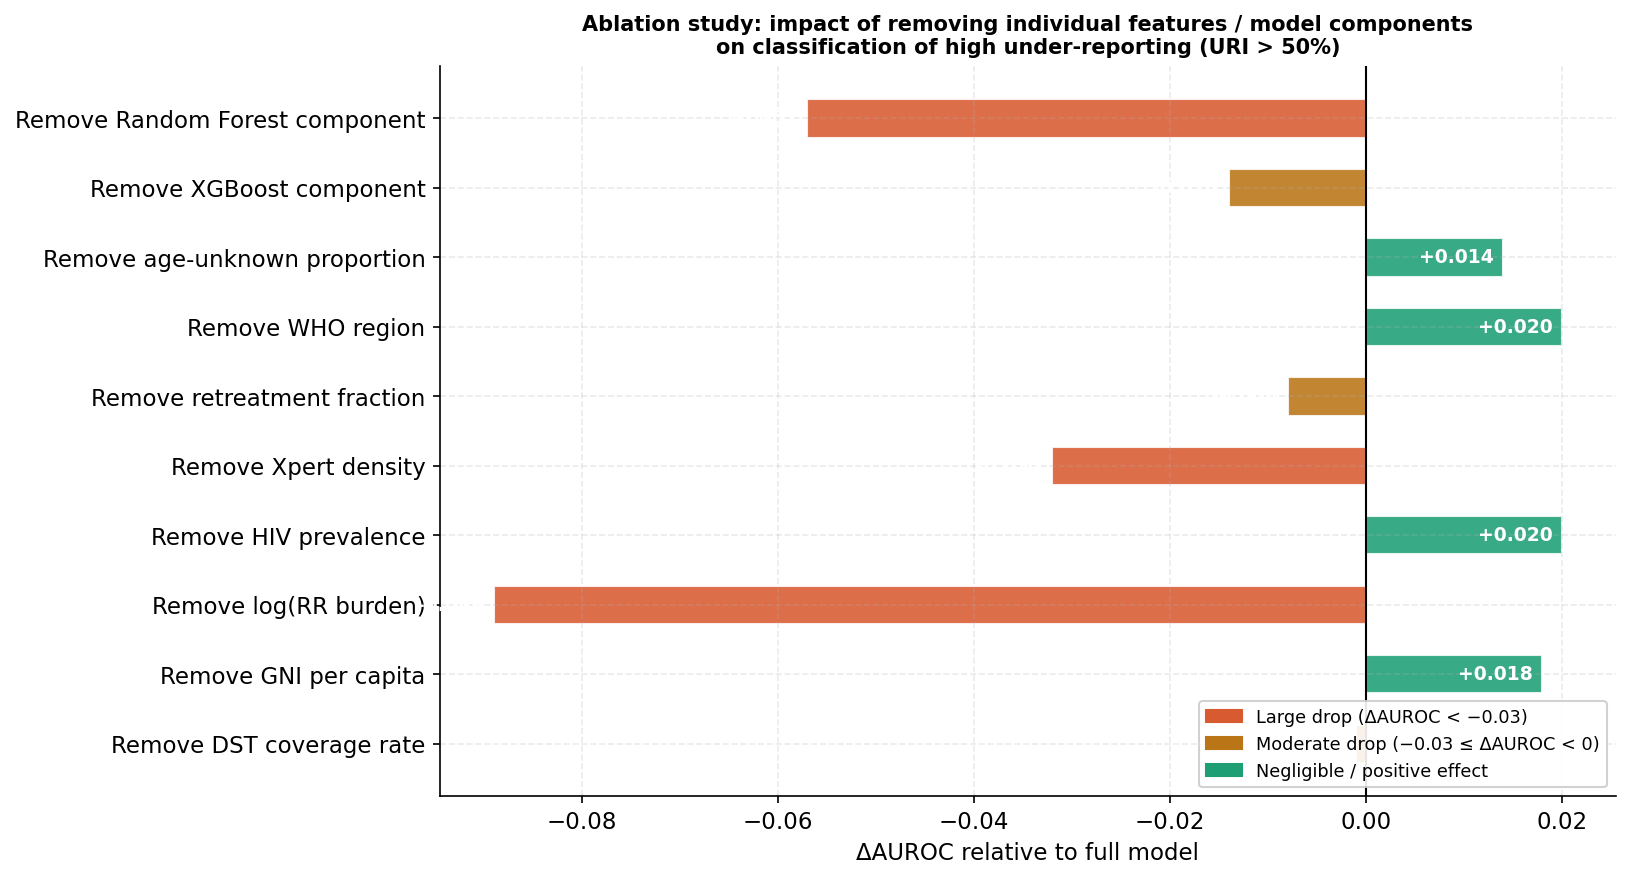

✓ Fig 8 saved


In [22]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 20 — FIGURE 8: Ablation study bar chart                             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

fig, ax = plt.subplots(figsize=(11, 6))
ab = ablation_df.copy()
ab['ΔAUROC_num'] = pd.to_numeric(ab['ΔAUROC'], errors='coerce').fillna(0)
ab = ab[ab['Configuration'] != 'Full model (baseline)']

colors_abl = [PALETTE['coral'] if d < -0.03 else
              (PALETTE['amber'] if d < 0 else PALETTE['teal'])
              for d in ab['ΔAUROC_num']]
bars = ax.barh(ab['Configuration'], ab['ΔAUROC_num'],
               color=colors_abl, edgecolor='white', height=0.55, alpha=0.88)
for bar, val in zip(bars, ab['ΔAUROC_num']):
    ax.text(val - 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', ha='right', va='center', fontsize=9, color='white',
            fontweight='bold')
ax.axvline(0, color='black', lw=1.0)
ax.set_xlabel('ΔAUROC relative to full model')
ax.set_title('Ablation study: impact of removing individual features / model components\n'
             'on classification of high under-reporting (URI > 50%)',
             fontsize=10, fontweight='bold')

legend_items = [
    mpatches.Patch(color=PALETTE['coral'],  label='Large drop (ΔAUROC < −0.03)'),
    mpatches.Patch(color=PALETTE['amber'],  label='Moderate drop (−0.03 ≤ ΔAUROC < 0)'),
    mpatches.Patch(color=PALETTE['teal'],   label='Negligible / positive effect'),
]
ax.legend(handles=legend_items, loc='lower right', fontsize=8.5)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'fig8_ablation.png')
plt.show()
print("✓ Fig 8 saved")





---
## CELL 21 — SHAP analysis (Figs 9–12)


Computing SHAP values (TreeSHAP)...


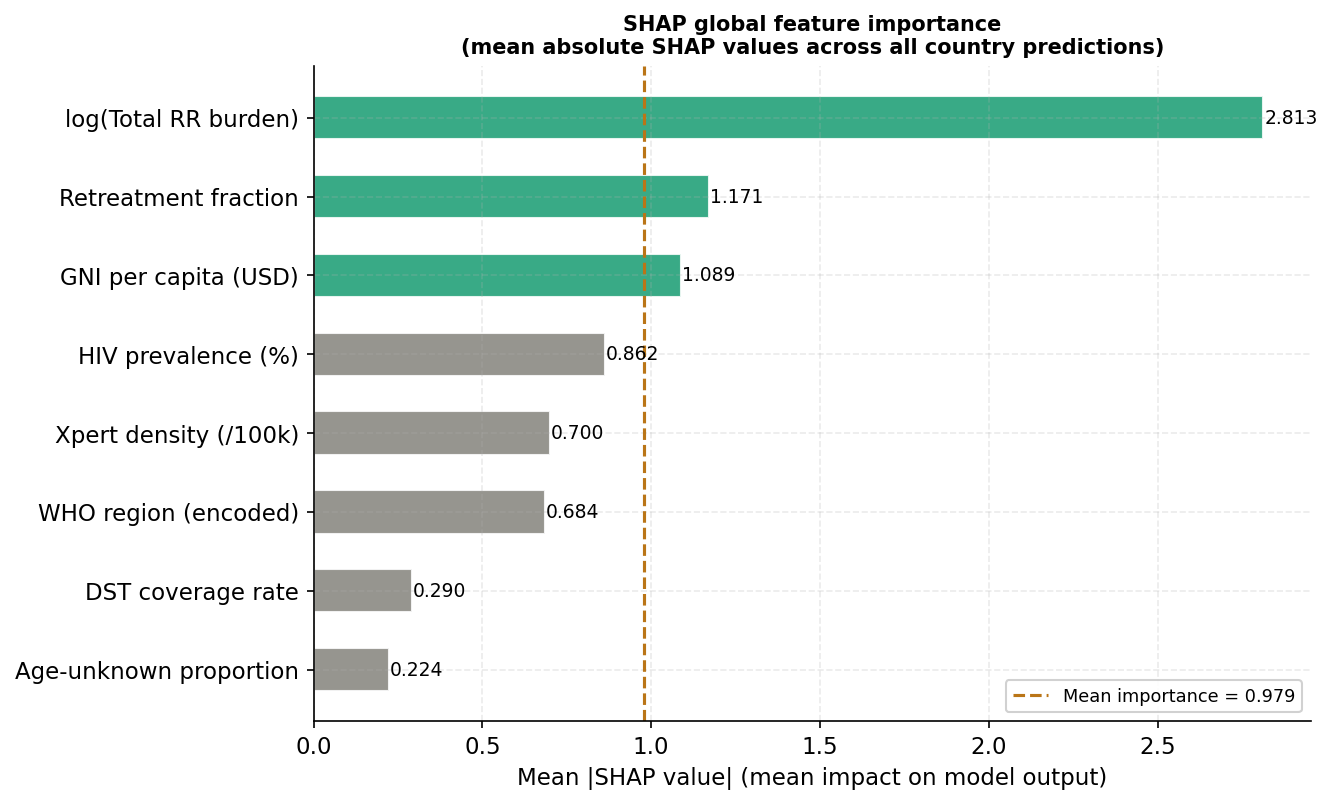

✓ Fig 9 (SHAP bar) saved


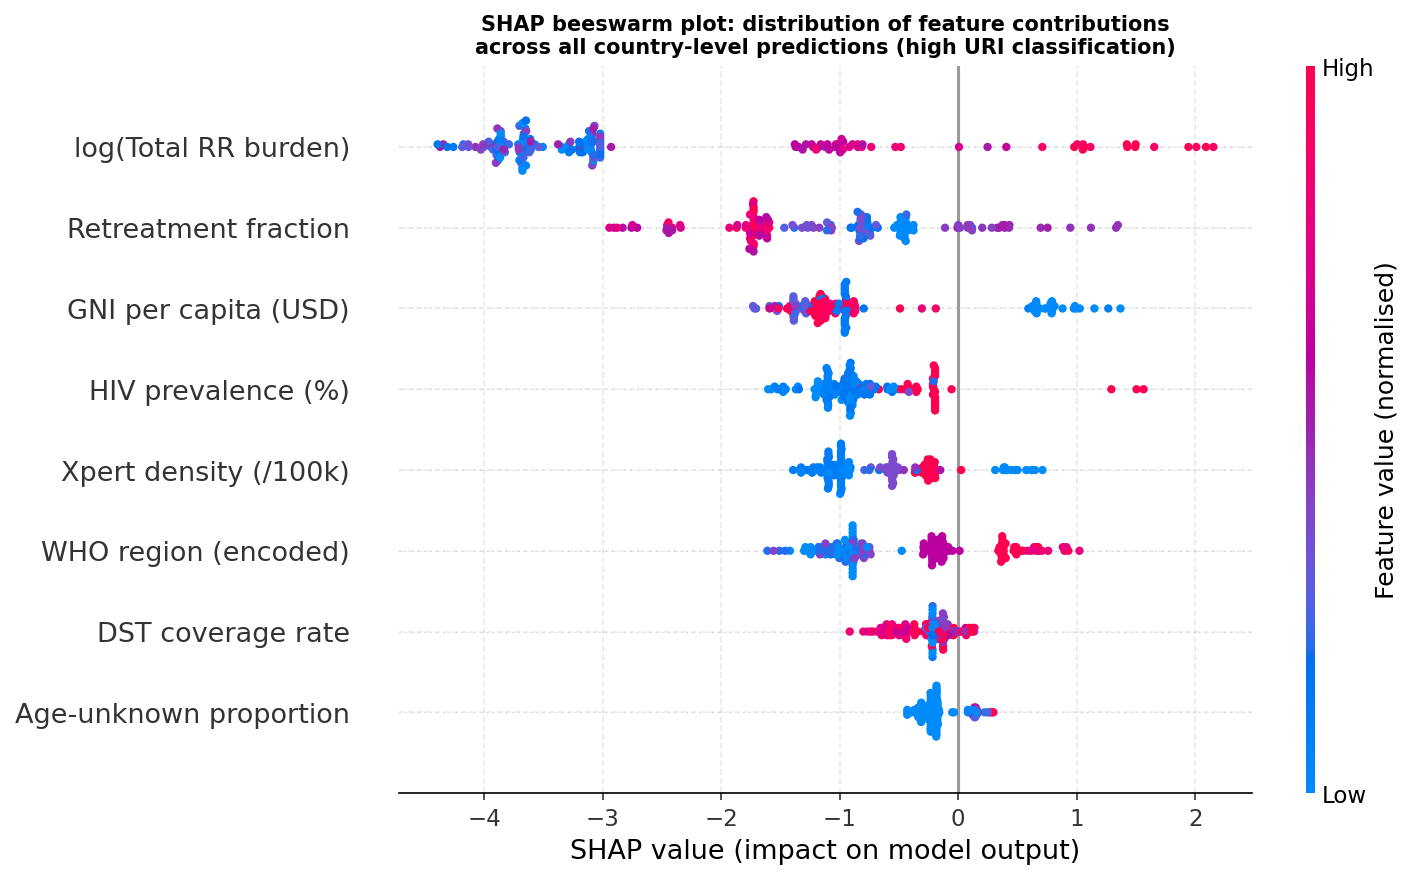

✓ Fig 10 (SHAP beeswarm) saved


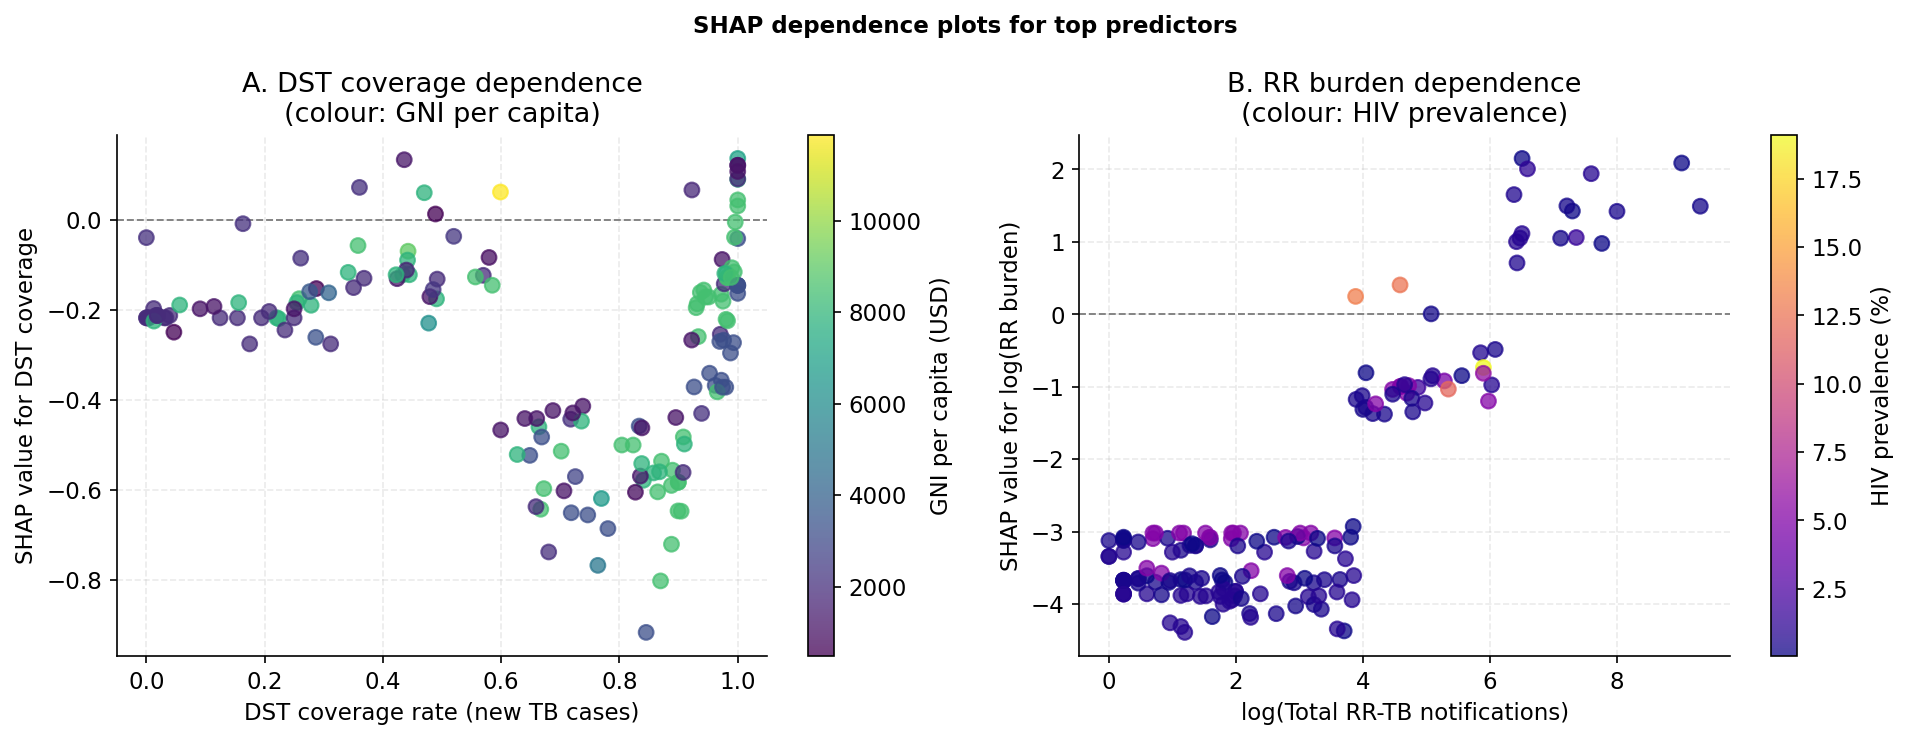

✓ Fig 11 (SHAP dependence) saved


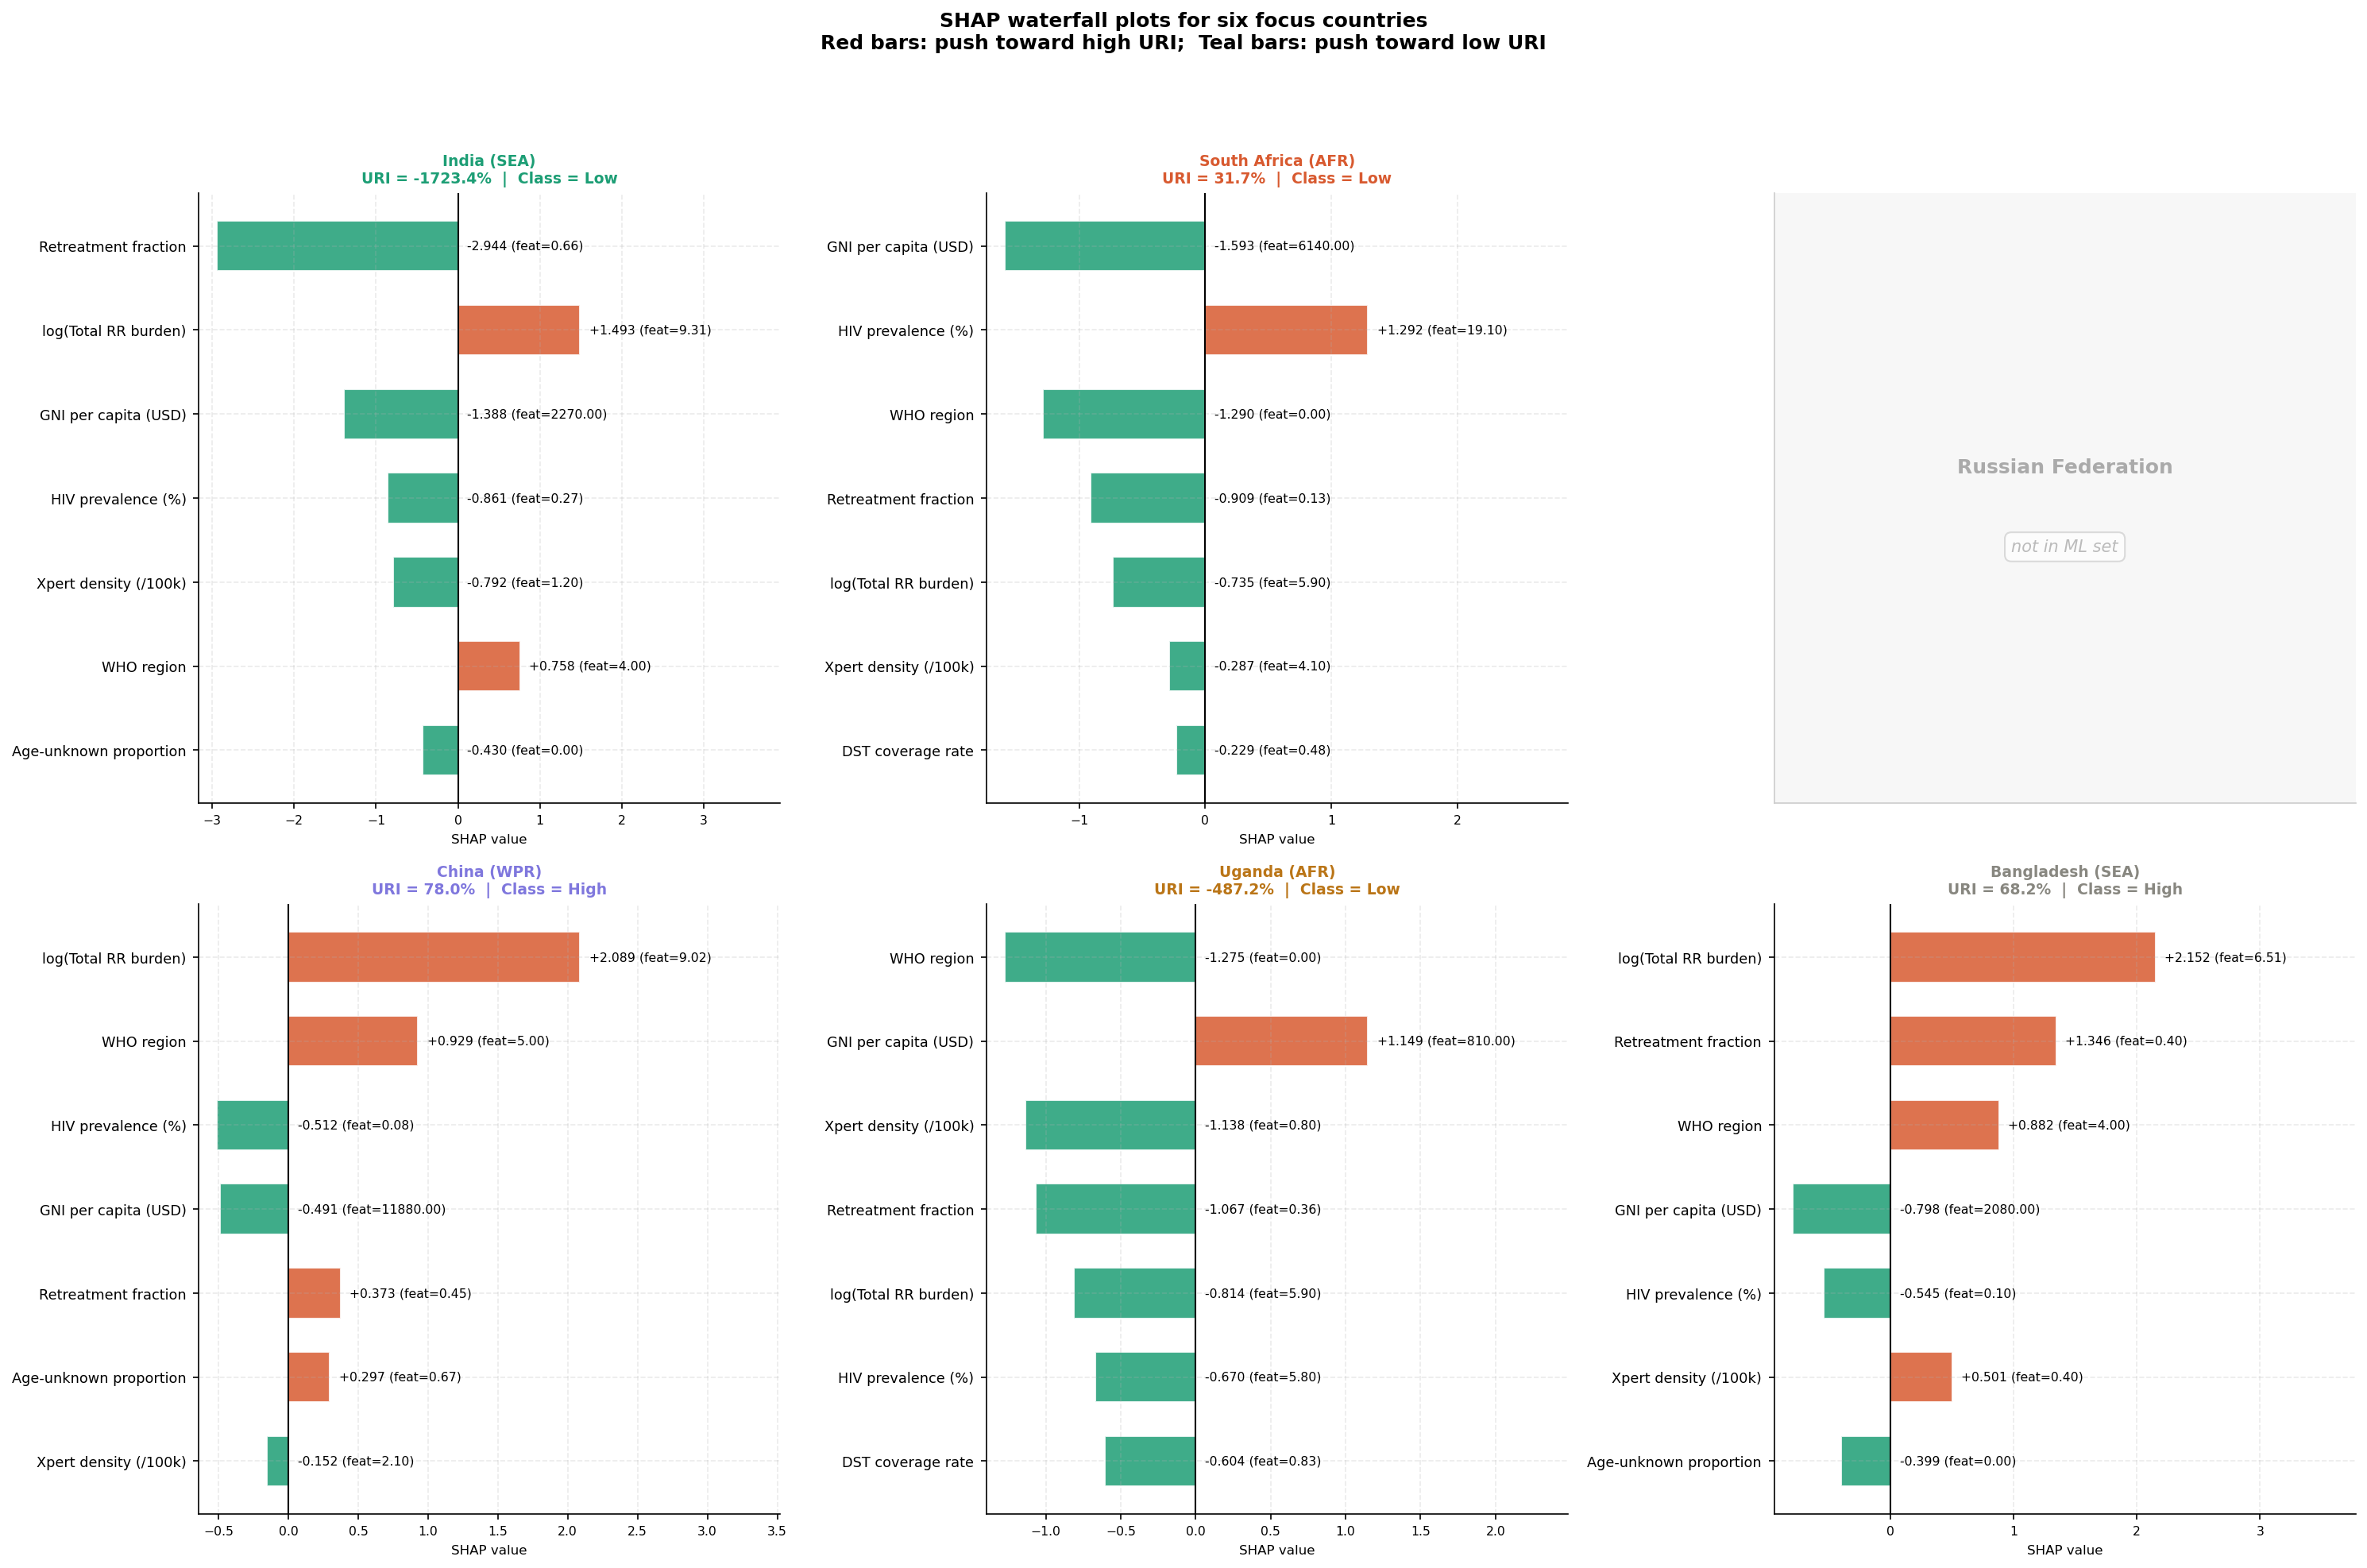

✓ Fig 12 (SHAP waterfall) saved


In [34]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 21 — SHAP analysis (Figs 9–12)                                      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("Computing SHAP values (TreeSHAP)...")
explainer    = shap.TreeExplainer(xgb_model)
shap_values  = explainer.shap_values(X)
expected_val = explainer.expected_value

# ── FIG 9: SHAP summary (bar) ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5.5))
mean_shap = np.abs(shap_values).mean(axis=0)
order     = np.argsort(mean_shap)
colors_sh = [PALETTE['teal'] if v > mean_shap.mean() else PALETTE['gray']
             for v in mean_shap[order]]
bars = ax.barh(np.array(FEAT_NAMES_DISP)[order], mean_shap[order],
               color=colors_sh, edgecolor='white', height=0.55, alpha=0.88)
for bar, val in zip(bars, mean_shap[order]):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlabel('Mean |SHAP value| (mean impact on model output)')
ax.set_title('SHAP global feature importance\n'
             '(mean absolute SHAP values across all country predictions)',
             fontsize=10, fontweight='bold')
ax.axvline(mean_shap.mean(), ls='--', color=PALETTE['amber'],
           label=f'Mean importance = {mean_shap.mean():.3f}')
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'fig9_shap_bar.png')
plt.show()
print("✓ Fig 9 (SHAP bar) saved")

# ── FIG 10: SHAP beeswarm ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values, X, feature_names=FEAT_NAMES_DISP,
                  plot_type='dot', max_display=8,
                  color_bar_label='Feature value (normalised)',
                  show=False, plot_size=(10, 6))
plt.title('SHAP beeswarm plot: distribution of feature contributions\n'
          'across all country-level predictions (high URI classification)',
          fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS_DIR / 'fig10_shap_beeswarm.png')
plt.show()
print("✓ Fig 10 (SHAP beeswarm) saved")

# ── FIG 11: SHAP dependence plot — DST coverage ───────────────────────────────
dst_idx = FEATURES.index('dst_cov_new')
gni_idx = FEATURES.index('gni_usd')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sc = axes[0].scatter(X[:, dst_idx], shap_values[:, dst_idx],
                     c=X[:, gni_idx], cmap='viridis', alpha=0.75, s=50, zorder=3)
plt.colorbar(sc, ax=axes[0], label='GNI per capita (USD)')
axes[0].axhline(0, ls='--', color='gray', lw=0.9)
axes[0].set_xlabel('DST coverage rate (new TB cases)')
axes[0].set_ylabel('SHAP value for DST coverage')
axes[0].set_title('A. DST coverage dependence\n(colour: GNI per capita)')

rr_idx  = FEATURES.index('log_rr_new')
hiv_idx = FEATURES.index('hiv_prev_pct')
sc2 = axes[1].scatter(X[:, rr_idx], shap_values[:, rr_idx],
                      c=X[:, hiv_idx], cmap='plasma', alpha=0.75, s=50, zorder=3)
plt.colorbar(sc2, ax=axes[1], label='HIV prevalence (%)')
axes[1].axhline(0, ls='--', color='gray', lw=0.9)
axes[1].set_xlabel('log(Total RR-TB notifications)')
axes[1].set_ylabel('SHAP value for log(RR burden)')
axes[1].set_title('B. RR burden dependence\n(colour: HIV prevalence)')

fig.suptitle('SHAP dependence plots for top predictors',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS_DIR / 'fig11_shap_dependence.png')
plt.show()
print("✓ Fig 11 (SHAP dependence) saved")

# ── FIG 12: SHAP waterfall — six focus countries ──────────────────────────────
FOCUS_COUNTRIES = {
    'India':              PALETTE['teal'],
    'South Africa':       PALETTE['coral'],
    'Russian Federation': PALETTE['blue'],
    'China':              PALETTE['purple'],
    'Uganda':             PALETTE['amber'],
    'Bangladesh':         PALETTE['gray'],
}

fig, axes = plt.subplots(2, 3, figsize=(20, 13))
axes = axes.flatten()

for idx, (cname, col) in enumerate(FOCUS_COUNTRIES.items()):
    ax  = axes[idx]
    row = ml_df[ml_df['country'] == cname]

    # ── Missing country: styled placeholder ──────────────────────────────────
    if len(row) == 0:
        ax.set_facecolor('#f7f7f7')
        for spine in ax.spines.values():
            spine.set_edgecolor('#cccccc')
        ax.text(0.5, 0.55, cname, ha='center', va='center',
                transform=ax.transAxes, fontsize=12, fontweight='bold',
                color='#aaaaaa')
        ax.text(0.5, 0.42, 'not in ML set', ha='center', va='center',
                transform=ax.transAxes, fontsize=10, style='italic',
                color='#bbbbbb',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                          edgecolor='#cccccc', alpha=0.7))
        ax.set_xticks([])
        ax.set_yticks([])
        continue

    # ── SHAP data for this country ────────────────────────────────────────────
    i_row     = row.index[0]
    j         = ml_df.index.get_loc(i_row)
    sv        = shap_values[j]
    uri_v     = row['uri'].values[0]
    region    = row['g_whoregion'].values[0]
    feat_vals = X[j]

    pairs = sorted(zip(sv, FEAT_NAMES_DISP, feat_vals),
                   key=lambda x: abs(x[0]), reverse=True)[:7]
    names  = [p[1].replace(' (encoded)', '') for p in pairs]   # cleaner labels
    svals  = [p[0] for p in pairs]
    fvals  = [p[2] for p in pairs]

    bar_colors = [PALETTE['coral'] if s > 0 else PALETTE['teal'] for s in svals]
    bars = ax.barh(names[::-1], svals[::-1], color=bar_colors[::-1],
                   edgecolor='white', height=0.6, alpha=0.85)

    # ── Dynamic axis range + annotation offset ────────────────────────────────
    x_lo    = min(min(svals), 0)
    x_hi    = max(max(svals), 0)
    x_range = max(x_hi - x_lo, 0.5)          # guard against near-zero range
    offset  = x_range * 0.025                 # small gap from bar tip / zero line

    for bar, sv_v, fv in zip(bars, svals[::-1], fvals[::-1]):
        label = f'{sv_v:+.3f} (feat={fv:.2f})'
        xpos  = bar.get_width()

        if xpos >= 0:
            # Positive bar → annotate to the right of bar tip
            ann_x, ann_ha = xpos + offset, 'left'
        else:
            # Negative bar → annotate just right of the zero line
            # (keeps left side free for y-axis labels)
            ann_x, ann_ha = offset, 'left'

        ax.text(ann_x, bar.get_y() + bar.get_height() / 2,
                label, va='center', ha=ann_ha, fontsize=7.5, clip_on=False)

    ax.axvline(0, color='black', lw=1.0)

    # Extra right padding so annotations are never clipped
    ax.set_xlim(x_lo - x_range * 0.05,
                x_hi + x_range * 0.55)

    # ── Titles & labels ───────────────────────────────────────────────────────
    cls_label = 'High' if uri_v > 50 else 'Low'
    ax.set_title(
        f'{cname} ({region})\nURI = {uri_v:.1f}%  |  Class = {cls_label}',
        fontsize=9, fontweight='bold', color=col, pad=6)
    ax.set_xlabel('SHAP value', fontsize=8)
    ax.tick_params(axis='y', labelsize=8.5, pad=4)
    ax.tick_params(axis='x', labelsize=7.5)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(
    'SHAP waterfall plots for six focus countries\n'
    'Red bars: push toward high URI;  Teal bars: push toward low URI',
    fontsize=12, fontweight='bold', y=1.01)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(FIGS_DIR / 'fig12_shap_waterfall_countries.png',
            dpi=180, bbox_inches='tight')
plt.show()
print("✓ Fig 12 (SHAP waterfall) saved")





---
## CELL 22 — LIME explanations (Figs 13–17, one per focus country)



Generating LIME explanations...


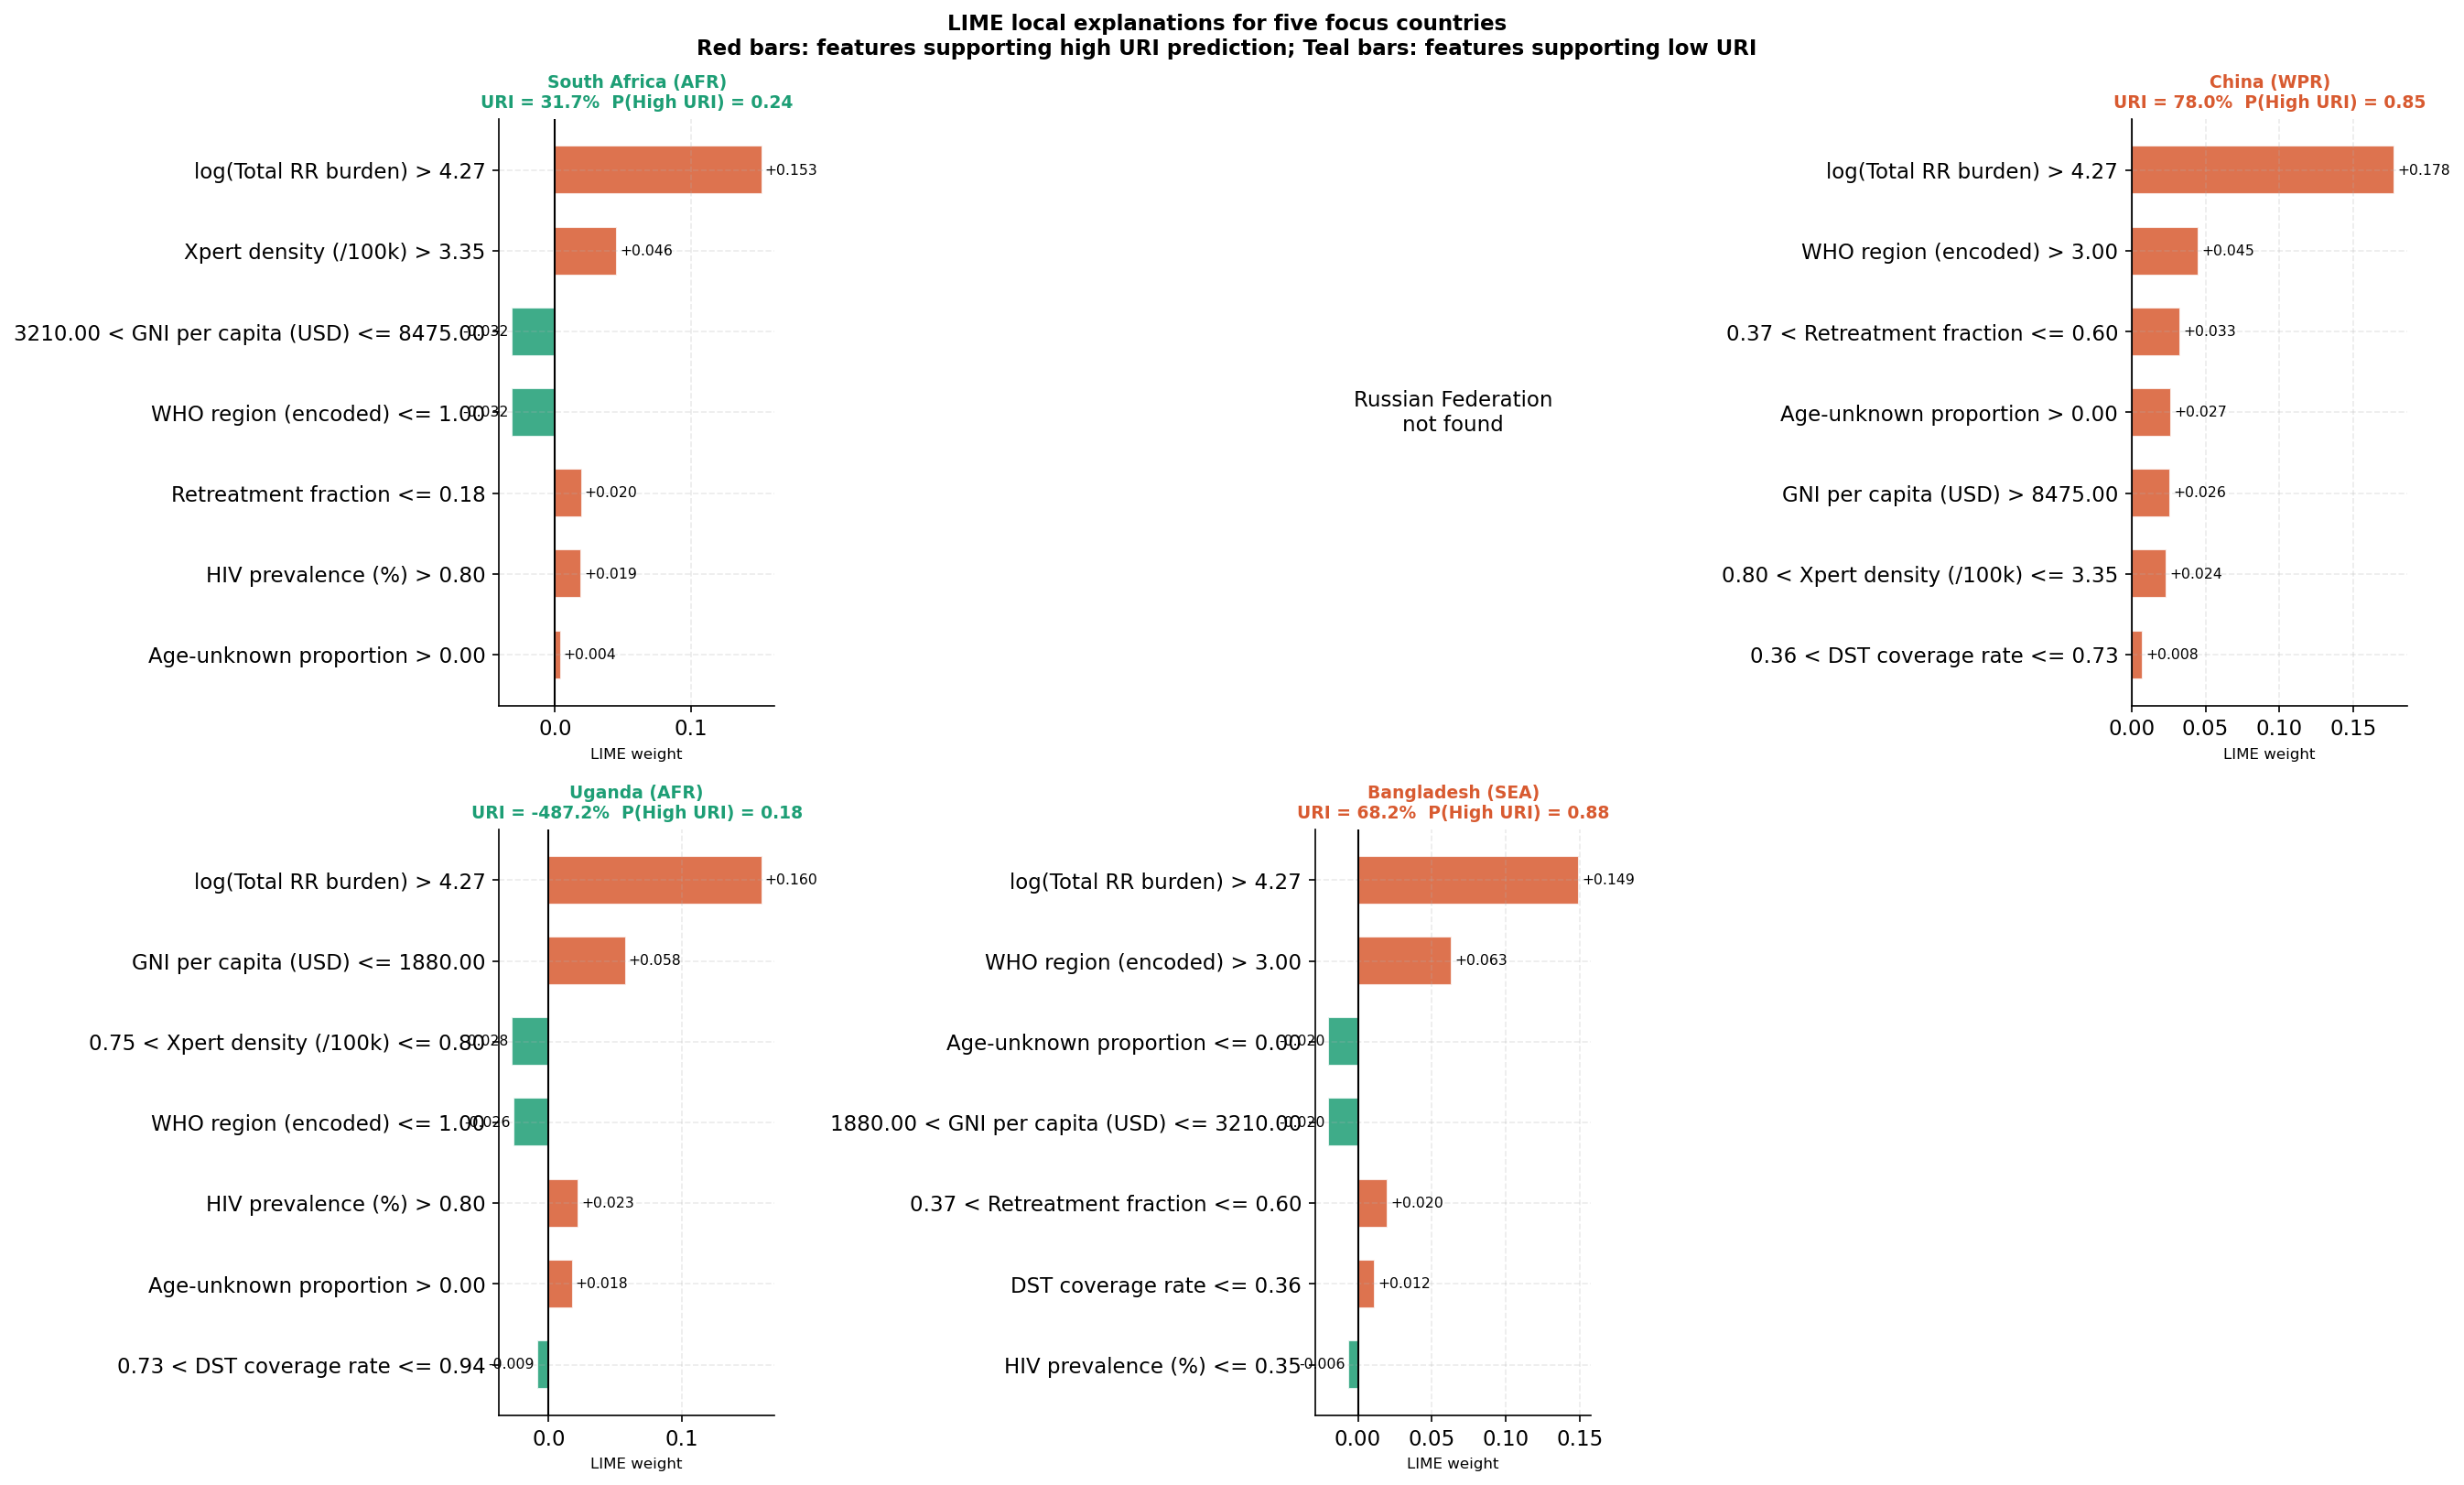

✓ Figs 13–17 (LIME per country) saved
  ✓ LIME figure saved: South Africa
  ✓ LIME figure saved: China
  ✓ LIME figure saved: Uganda
  ✓ LIME figure saved: Bangladesh


In [33]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 22 — LIME explanations (Figs 13–17, one per focus country)           ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("\nGenerating LIME explanations...")

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X,
    feature_names=FEAT_NAMES_DISP,
    class_names=['Low URI', 'High URI'],
    mode='classification',
    discretize_continuous=True,
    random_state=42,
)

def predict_proba_ens(x):
    p_rf  = rf_model.predict_proba(x)[:, 1]
    p_xgb = xgb_model.predict_proba(x)[:, 1]
    p_ens = 0.45 * p_rf + 0.55 * p_xgb
    return np.column_stack([1 - p_ens, p_ens])

def clean_lime_label(label):
    """Strip ' (encoded)' and tighten long LIME condition strings."""
    label = label.replace(' (encoded)', '')
    # LIME discretises to e.g. '2.50 < feat <= 5.00'; shorten if too long
    if len(label) > 40:
        label = label[:38] + '…'
    return label

# ── Combined overview figure (2 × 3 grid) ─────────────────────────────────────
LIME_COUNTRIES = ['South Africa', 'Russian Federation', 'China',
                  'Uganda', 'Bangladesh']

lime_fig, lime_axes = plt.subplots(2, 3, figsize=(22, 14))
lime_axes = lime_axes.flatten()

for idx, cname in enumerate(LIME_COUNTRIES):
    ax  = lime_axes[idx]
    row = ml_df[ml_df['country'] == cname]

    # ── Missing country: styled placeholder ──────────────────────────────────
    if len(row) == 0:
        ax.set_facecolor('#f7f7f7')
        for spine in ax.spines.values():
            spine.set_edgecolor('#cccccc')
        ax.text(0.5, 0.55, cname, ha='center', va='center',
                transform=ax.transAxes, fontsize=12, fontweight='bold',
                color='#aaaaaa')
        ax.text(0.5, 0.42, 'not in ML set', ha='center', va='center',
                transform=ax.transAxes, fontsize=10, style='italic',
                color='#bbbbbb',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                          edgecolor='#cccccc', alpha=0.7))
        ax.set_xticks([])
        ax.set_yticks([])
        continue

    i_row  = row.index[0]
    j      = ml_df.index.get_loc(i_row)
    x_inst = X[j].reshape(1, -1)
    uri_v  = row['uri'].values[0]
    region = row['g_whoregion'].values[0]

    exp = lime_explainer.explain_instance(
        X[j], predict_proba_ens,
        num_features=7, num_samples=1000)

    feat_list  = exp.as_list()
    feat_names = [clean_lime_label(f[0]) for f in feat_list]
    feat_vals  = [f[1] for f in feat_list]
    bar_colors = [PALETTE['coral'] if v > 0 else PALETTE['teal']
                  for v in feat_vals]

    bars = ax.barh(feat_names[::-1], feat_vals[::-1],
                   color=bar_colors[::-1], edgecolor='white',
                   height=0.6, alpha=0.85)

    # ── Dynamic axis range + annotation offset ────────────────────────────────
    x_lo    = min(min(feat_vals), 0)
    x_hi    = max(max(feat_vals), 0)
    x_range = max(x_hi - x_lo, 0.05)
    offset  = x_range * 0.025

    for bar, fv in zip(bars, feat_vals[::-1]):
        xpos = bar.get_width()
        if xpos >= 0:
            ann_x, ann_ha = xpos + offset, 'left'
        else:
            # Anchor negative-bar labels just right of zero → y-axis stays clear
            ann_x, ann_ha = offset, 'left'
        ax.text(ann_x, bar.get_y() + bar.get_height() / 2,
                f'{fv:+.3f}', va='center', ha=ann_ha,
                fontsize=7.5, clip_on=False)

    ax.axvline(0, color='black', lw=1.0)
    ax.set_xlim(x_lo - x_range * 0.05,
                x_hi + x_range * 0.50)   # right padding for annotations

    proba_high = predict_proba_ens(x_inst)[0, 1]
    cls_label  = 'High' if uri_v > 50 else 'Low'
    ax.set_title(
        f'{cname} ({region})\n'
        f'URI = {uri_v:.1f}%  |  Class = {cls_label}  |  P(High) = {proba_high:.2f}',
        fontsize=9, fontweight='bold',
        color=PALETTE['coral'] if uri_v > 50 else PALETTE['teal'],
        pad=6)
    ax.set_xlabel('LIME weight', fontsize=8)
    ax.tick_params(axis='y', labelsize=8.5, pad=4)
    ax.tick_params(axis='x', labelsize=7.5)
    ax.spines[['top', 'right']].set_visible(False)

# ── Blank last panel: styled, not just invisible ──────────────────────────────
ax_last = lime_axes[-1]
ax_last.set_facecolor('#f7f7f7')
for spine in ax_last.spines.values():
    spine.set_edgecolor('#cccccc')
ax_last.set_xticks([])
ax_last.set_yticks([])

lime_fig.suptitle(
    'LIME local explanations for five focus countries\n'
    'Red bars: features supporting high URI prediction;  '
    'Teal bars: features supporting low URI prediction',
    fontsize=12, fontweight='bold', y=1.01)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(FIGS_DIR / 'fig13_17_lime_countries.png',
            dpi=180, bbox_inches='tight')
plt.show()
print("✓ Figs 13–17 (LIME overview) saved")


# ── Individual LIME figures (one per country for paper submission) ─────────────
for cname in LIME_COUNTRIES:
    row = ml_df[ml_df['country'] == cname]
    if len(row) == 0:
        print(f"  ⚠ Skipping {cname} — not in ML set")
        continue

    j      = ml_df.index.get_loc(row.index[0])
    uri_v  = row['uri'].values[0]
    region = row['g_whoregion'].values[0]

    exp        = lime_explainer.explain_instance(
        X[j], predict_proba_ens, num_features=7, num_samples=1000)
    feat_list  = exp.as_list()
    fn         = [clean_lime_label(f[0]) for f in feat_list]
    fv         = [f[1] for f in feat_list]
    bc         = [PALETTE['coral'] if v > 0 else PALETTE['teal'] for v in fv]

    fig_l, ax_l = plt.subplots(figsize=(10, 5))
    bars = ax_l.barh(fn[::-1], fv[::-1], color=bc[::-1],
                     edgecolor='white', height=0.55, alpha=0.88)

    # ── Same annotation logic as overview ─────────────────────────────────────
    x_lo    = min(min(fv), 0)
    x_hi    = max(max(fv), 0)
    x_range = max(x_hi - x_lo, 0.05)
    offset  = x_range * 0.025

    for bar, v in zip(bars, fv[::-1]):
        xpos = bar.get_width()
        if xpos >= 0:
            ann_x, ann_ha = xpos + offset, 'left'
        else:
            ann_x, ann_ha = offset, 'left'
        ax_l.text(ann_x, bar.get_y() + bar.get_height() / 2,
                  f'{v:+.3f}', va='center', ha=ann_ha,
                  fontsize=8, clip_on=False)

    ax_l.axvline(0, color='black', lw=1.0)
    ax_l.set_xlim(x_lo - x_range * 0.05,
                  x_hi + x_range * 0.50)

    proba_high = predict_proba_ens(X[j].reshape(1, -1))[0, 1]
    cls_label  = 'High' if uri_v > 50 else 'Low'
    ax_l.set_title(
        f'LIME explanation — {cname} ({region})\n'
        f'URI = {uri_v:.1f}%  |  Class = {cls_label}  |  '
        f'P(High under-reporting) = {proba_high:.2f}',
        fontsize=10, fontweight='bold',
        color=PALETTE['coral'] if uri_v > 50 else PALETTE['teal'])
    ax_l.set_xlabel('LIME contribution weight', fontsize=9)
    ax_l.tick_params(axis='y', labelsize=9, pad=4)
    ax_l.tick_params(axis='x', labelsize=8)
    ax_l.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    safe_name = cname.lower().replace(' ', '_').replace('/', '_')
    plt.savefig(FIGS_DIR / f'lime_{safe_name}.png',
                dpi=180, bbox_inches='tight')
    plt.close()
    print(f"  ✓ LIME figure saved: {cname}")

---
## CELL 23 — FIGURE 18: URI heatmap (region × year)


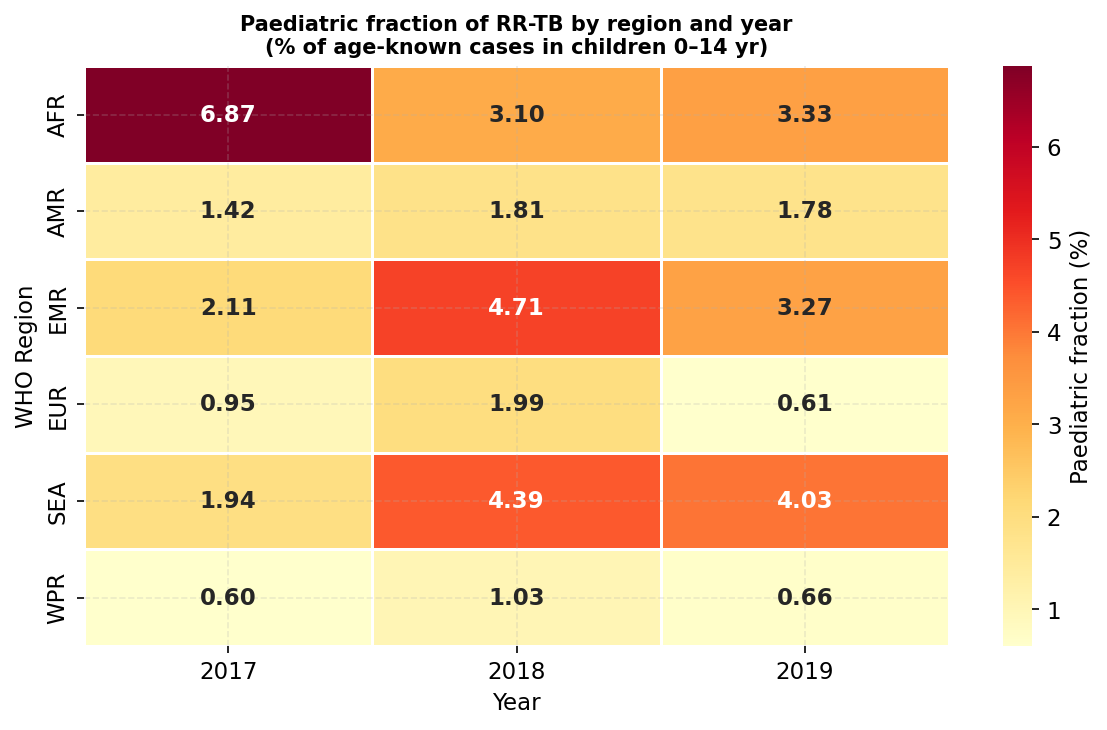

✓ Fig 18 saved


In [35]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 23 — FIGURE 18: URI heatmap (region × year)                        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# Compute year-specific regional paediatric fractions
yr_reg = (df_age.groupby(['g_whoregion', 'year'])
          .agg(rr_014=('rr_014', 'sum'),
               rr_15plus=('rr_15plus', 'sum'))
          .reset_index())
yr_reg['ped_pct'] = (yr_reg['rr_014'] /
                     (yr_reg['rr_014'] + yr_reg['rr_15plus']) * 100).round(2)
pivot = yr_reg.pivot(index='g_whoregion', columns='year', values='ped_pct')

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Paediatric fraction (%)'},
            annot_kws={'size': 11, 'weight': 'bold'})
ax.set_ylabel('WHO Region')
ax.set_xlabel('Year')
ax.set_title('Paediatric fraction of RR-TB by region and year\n'
             '(% of age-known cases in children 0–14 yr)',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS_DIR / 'fig18_uri_heatmap.png')
plt.show()
print("✓ Fig 18 saved")

---
## CELL 24 — FIGURE 19: URI ranking bar chart (top 20 countries)


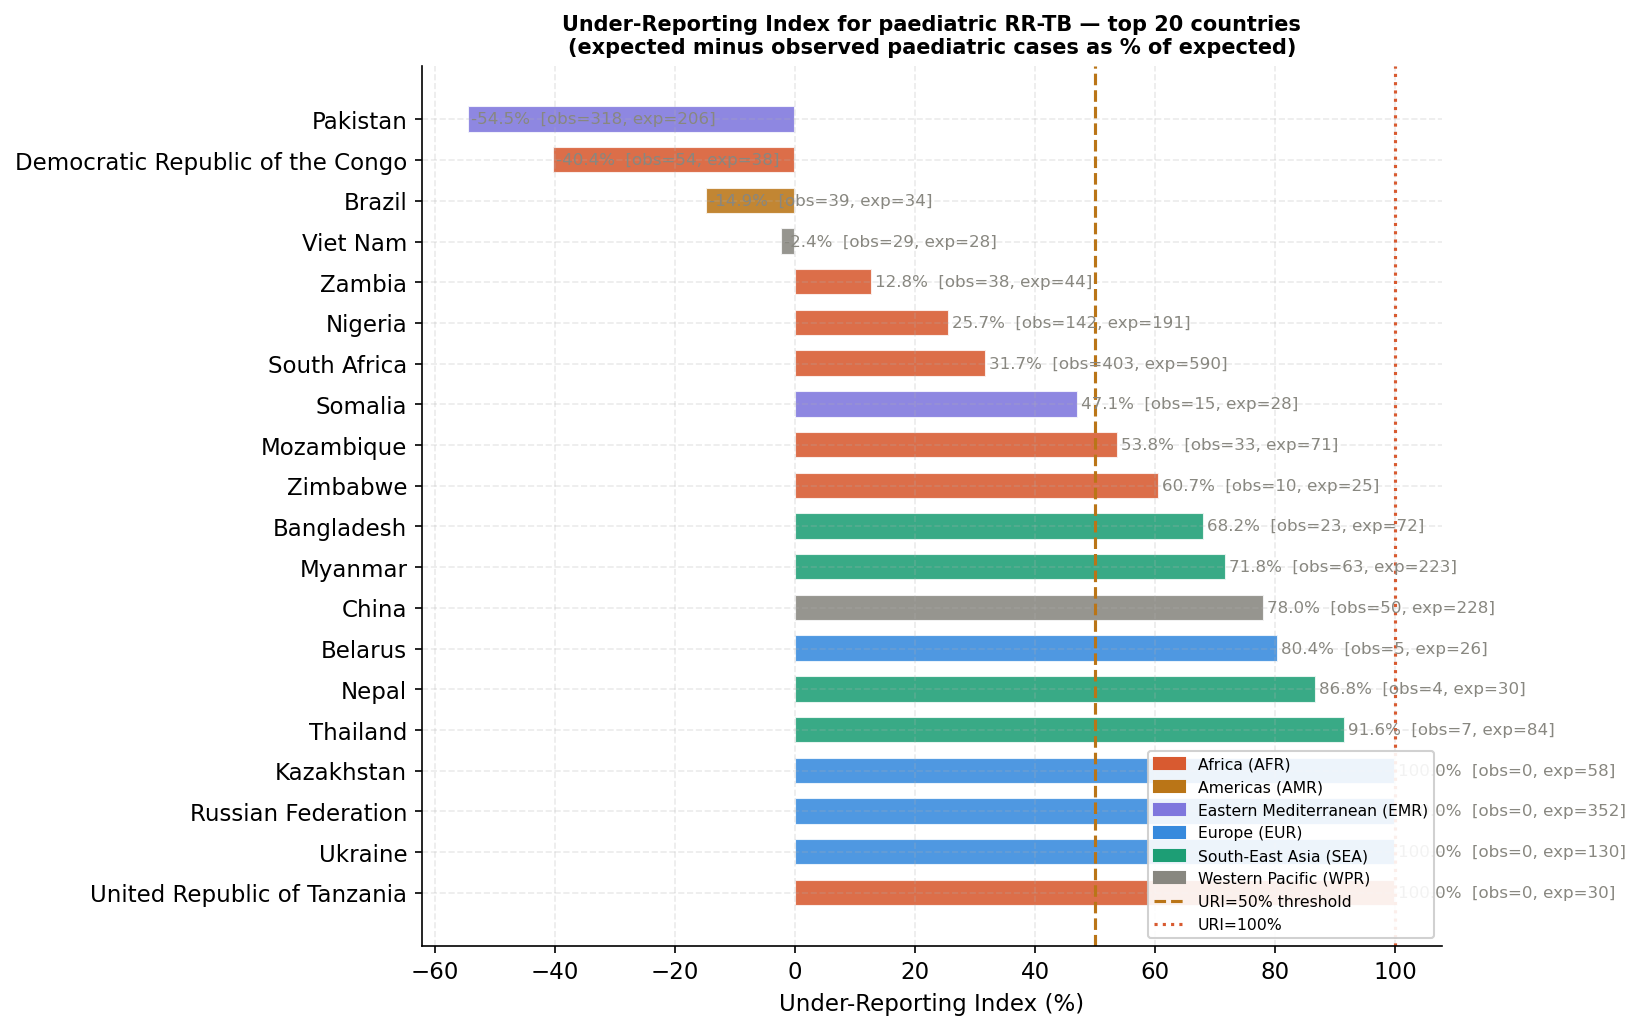

✓ Fig 19 saved


In [26]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 24 — FIGURE 19: URI ranking bar chart (top 20 countries)            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

top_uri = uri_df.nlargest(20, 'uri').copy()
top_uri['color'] = top_uri.apply(
    lambda r: REGION_COLOURS.get(r['g_whoregion'], PALETTE['gray']), axis=1)

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top_uri['country'], top_uri['uri'],
               color=top_uri['color'], edgecolor='white',
               height=0.65, alpha=0.88)
for bar, row in zip(bars, top_uri.itertuples()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{row.uri:.1f}%  [obs={int(row.obs_ped) if pd.notna(row.obs_ped) else 0},"
            f" exp={row.expected_ped:.0f}]",
            va='center', fontsize=8, color=PALETTE['gray'])
ax.axvline(50, ls='--', color=PALETTE['amber'],
           label='URI = 50% threshold', lw=1.5)
ax.axvline(100, ls=':', color=PALETTE['coral'],
           label='URI = 100% (zero reports)', lw=1.5)
ax.set_xlabel('Under-Reporting Index (%)')
ax.set_title('Under-Reporting Index for paediatric RR-TB — top 20 countries\n'
             '(expected minus observed paediatric cases as % of expected)',
             fontsize=10, fontweight='bold')

legend_patches = [mpatches.Patch(color=c, label=REGION_LABELS[r])
                  for r, c in REGION_COLOURS.items()]
legend_patches += [
    mlines.Line2D([0],[0], ls='--', color=PALETTE['amber'], label='URI=50% threshold'),
    mlines.Line2D([0],[0], ls=':',  color=PALETTE['coral'], label='URI=100%'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=7.5)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'fig19_uri_ranking.png')
plt.show()
print("✓ Fig 19 saved")





---
## CELL 25 — FIGURE 20: Age-unknown proportion (data quality)


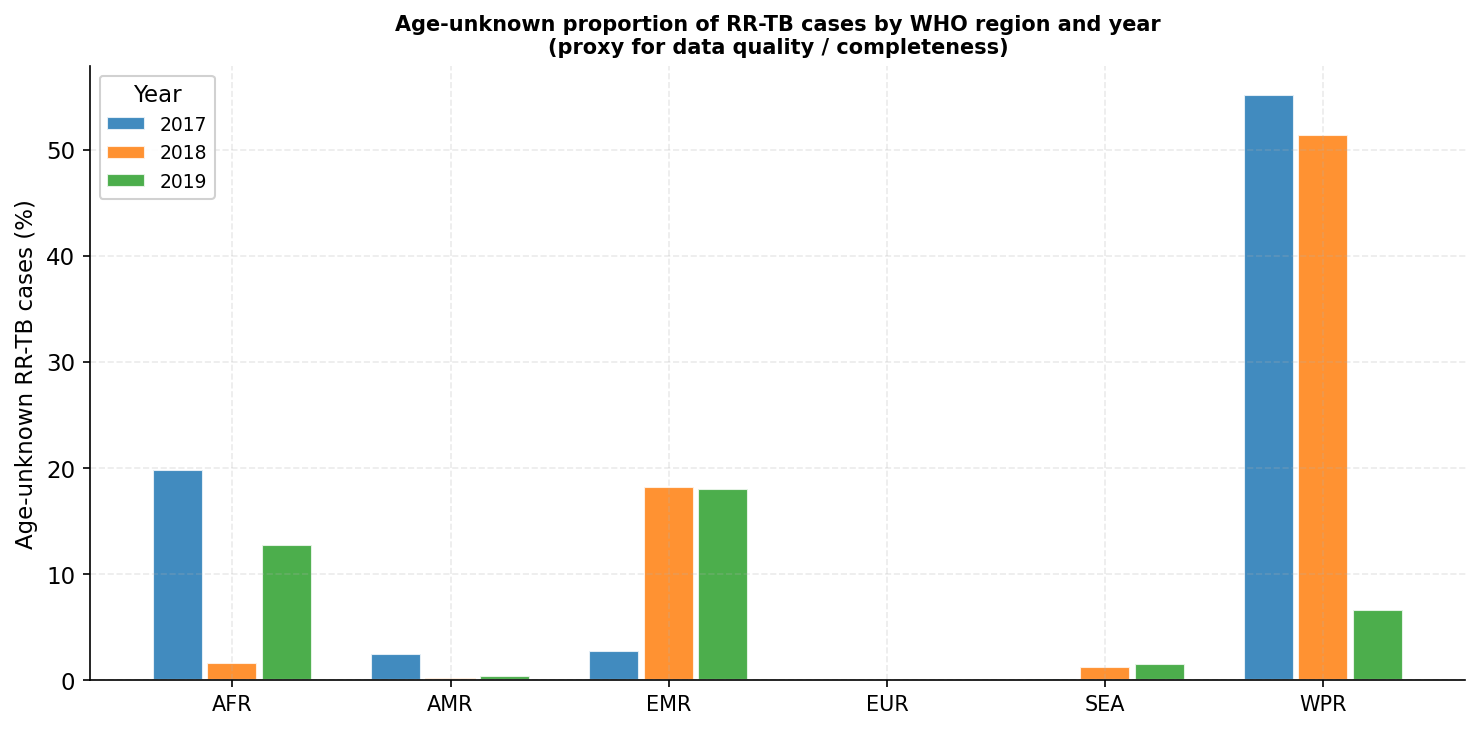

✓ Fig 20 saved


In [27]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 25 — FIGURE 20: Age-unknown proportion (data quality)               ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

unk_df = (df_age.groupby(['g_whoregion', 'year'])
          .agg(rr_014=('rr_014', 'sum'),
               rr_15plus=('rr_15plus', 'sum'),
               rr_ageunk=('rr_ageunk', 'sum'))
          .reset_index())
unk_df['total']    = unk_df['rr_014'] + unk_df['rr_15plus'] + unk_df['rr_ageunk'].fillna(0)
unk_df['unk_pct']  = (unk_df['rr_ageunk'] / unk_df['total'] * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
pivot_unk = unk_df.pivot_table(index='g_whoregion', columns='year',
                                values='unk_pct', aggfunc='mean')
x_pos = np.arange(len(pivot_unk))
width = 0.25
for i, yr in enumerate([2017, 2018, 2019]):
    if yr in pivot_unk.columns:
        bars = ax.bar(x_pos + i * width, pivot_unk[yr].fillna(0),
                      width=width - 0.02, label=str(yr),
                      alpha=0.85, edgecolor='white')

ax.set_xticks(x_pos + width)
ax.set_xticklabels(pivot_unk.index, fontsize=10)
ax.set_ylabel('Age-unknown RR-TB cases (%)')
ax.set_title('Age-unknown proportion of RR-TB cases by WHO region and year\n'
             '(proxy for data quality / completeness)',
             fontsize=10, fontweight='bold')
ax.legend(title='Year', fontsize=9)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'fig20_age_unknown.png')
plt.show()
print("✓ Fig 20 saved")





---
## CELL 26 — Summary report


In [28]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 26 — Summary report                                                 ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("\n" + "=" * 70)
print("  ANALYSIS COMPLETE — OUTPUT SUMMARY")
print("=" * 70)

import os
figs = sorted(FIGS_DIR.glob('*.png'))
tabs = sorted(TABS_DIR.glob('*.csv'))

print(f"\n  Figures saved ({len(figs)}):")
for f in figs:
    print(f"    {f.name}  ({os.path.getsize(f)/1024:.0f} KB)")

print(f"\n  Tables saved ({len(tabs)}):")
for t in tabs:
    print(f"    {t.name}")

print(f"\n  All outputs in: {OUTPUT_DIR.resolve()}")

print("""
────────────────────────────────────────────────────────────────────
  PAPER FIGURE MAP
────────────────────────────────────────────────────────────────────
  Fig 1   fig1_conceptual_framework.png   — Conceptual diagram
  Fig 2   fig2_flowchart.png              — Methodological flowchart
  Fig 3   fig3_ml_architecture.png        — ML pipeline architecture
  Fig 4   fig4_trends.png                 — Paediatric/adult trends
  Fig 5   fig5_regional_burden.png        — Regional breakdown
  Fig 6   fig6_uri_scatter.png            — Observed vs expected (URI)
  Fig 7   fig7_roc_pr_curves.png          — ROC + PR curves
  Fig 8   fig8_ablation.png               — Ablation study
  Fig 9   fig9_shap_bar.png               — SHAP global importance
  Fig 10  fig10_shap_beeswarm.png         — SHAP beeswarm
  Fig 11  fig11_shap_dependence.png       — SHAP dependence plots
  Fig 12  fig12_shap_waterfall_countries  — SHAP waterfall ×6
  Figs 13-17 fig13_17_lime_countries.png  — LIME ×5 countries
             lime_south_africa.png (etc.) — Individual LIME figs
  Fig 18  fig18_uri_heatmap.png           — URI heatmap
  Fig 19  fig19_uri_ranking.png           — URI top-20 bar
  Fig 20  fig20_age_unknown.png           — Data quality metric

  TABLE MAP
  Table 1  table1_global_surveillance.csv + .png
  Table 2  table2_regional_burden.csv
  Table 3  table3_country_burden.csv
  Table 4  table4_uri_top20.csv  +  table4_uri_all_countries.csv
  Table 5  table5_sota_comparison.csv + .png
  Table 6  table6_ablation.csv
────────────────────────────────────────────────────────────────────
""")




  ANALYSIS COMPLETE — OUTPUT SUMMARY

  Figures saved (22):
    fig10_shap_beeswarm.png  (368 KB)
    fig11_shap_dependence.png  (627 KB)
    fig12_shap_waterfall_countries.png  (735 KB)
    fig13_17_lime_countries.png  (710 KB)
    fig18_uri_heatmap.png  (156 KB)
    fig19_uri_ranking.png  (514 KB)
    fig1_conceptual_framework.png  (355 KB)
    fig20_age_unknown.png  (129 KB)
    fig2_flowchart.png  (442 KB)
    fig3_ml_architecture.png  (333 KB)
    fig4_trends.png  (247 KB)
    fig5_regional_burden.png  (306 KB)
    fig6_uri_scatter.png  (368 KB)
    fig7_roc_pr_curves.png  (341 KB)
    fig8_ablation.png  (291 KB)
    fig9_shap_bar.png  (220 KB)
    lime_bangladesh.png  (183 KB)
    lime_china.png  (183 KB)
    lime_south_africa.png  (185 KB)
    lime_uganda.png  (186 KB)
    table1_global_surveillance.png  (224 KB)
    table5_sota_comparison.png  (202 KB)

  Tables saved (7):
    table1_global_surveillance.csv
    table2_regional_burden.csv
    table3_country_burden.csv
    table